<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## TO DO

## see if I can't make my results line up with Das somehow, and with Prat another way
## -- doesn't have to be the SAME way, I just want to see if I can make that work

## fix correlation matrix plotting
## check physics of tracers
## consider changing params to match Planck

## Setup

In [3]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')
print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [4]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
import pandas as pd

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, mcsamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [5]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import instrument_Pk2D
from functions_and_classes import plot_cobaya_mcmc_results

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood
from functions_and_classes import FisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


## Summary of Problem and Investegations (and Solutions)

It's now July 9, 2026. In mid/late June, to test my pipeline, I tried to recreate the forecasts shown in the Prat lensing ratios paper. Setting it up took some time, and there was a decent amount of approximation along the way, since the exact data and noise used by Prat were not explicitly given. When I ran a Fisher forecast with their (approximate) setup, I got elliptical constraints with degeneracy directions that were different to the ones Prat got. I expected my results to be somewhat different from Prat's given the fact that I made approximations and was using a Fisher forecast, but I was really concerned about the degeneracy directions. 

Anton suggested that the discrepency was due to the lack of CMB primaries in my pipeline. Prat say that they use 'Planck geometric prior' which Anton understood to mean CMB primaries. I modified my functions, classes, and methods to include CMB primaries (I had to change things at many points along the pipeline, but it was overall a faster fix than I expected it to be since my functions and classes are so nicely modular.) The CMB primaries improved my constraints a lot, but they did not fix the degeneracy directions. I then added other parameters to the pipeline, namely T_CMB, m_nu, and Neff. I combed through my code and found two errors: a scaling error with the CMB primaries, and a swap of galaxy lensing and lens galaxy tracers in one place. Along the way I also changed my labeling to be more clear for the different types of tracers. I tested my Fishers were lots of different combinations of parameters in an effort to figure out how different parameters affected one another, and in the hope that I'd find something that looked more similar to Prat. Still, my degeneracy directions were off. On Tuesday July 7, Anton suggested that maybe Prat was wrong -- he had faith in my pipeline. We decided to compare with Das and Spergel too. 

After the meeting I ran a few more Fishers with different parameters isolated (namely the main three plotted plus h OR omega_b). I also modified my pipeline to take an l_min parameter so we can easy change both the lower and upper bounds of the multipoles. I looked through the Das paper and realized even before modifying my Fisher class to allow for plots of omega_lambda that my plots would not have the same degeneracy directions as theirs. In short, I traced the degeneracy directions of different parameters and I concluded that the main source of the error was the degeneracy direction between omega_m and omega_k. I sampled over omega_b and omega_k and then over omega_c and omega_k. When I ran the Prat Fisher for omega_b, omega_k, w0, and h, and treated omega_b like omega_m, I got the right degeneracy directions. When I did the same thing with omega_c, I got the wrong degeneracy directions. I started to think that the issue was something with omega_c and its affect on omega_m. 

Omega_m is a derived parameter, and neither PyCCL nor CAMB can take it in to create a cosmology object, so we have to get it from other parameters. Simply saying "omega_m was varied" is generally insufficient because omega_m is not a primary pyccl parameter but a derived one. As I had it, Omega_c was defined as the difference between Omega_m and Omega_b (I did this because we generally were not interested in plotting Omega_c). However, this setup meant that when we varied Omega_m we were effectively just varying Omega_c. This is of course not the only way to change Omega_m, and is not, I started to believe, the way that the other papers varied Omega_m. I updated the Fisher class so that the fundamental cosmology parameters, the ones we can put into PyCCL, are varied (or some subset of them), and that the constraints parameters we wish to plot are extracted from the constraints on those fundamental parameters. 

I found that if I sample over the four parameters explicitly mentioned in Prat -- omega_b, omega_k, w0, and h -- and then plot omega_k, omega_m, and w0, I get a decent approximation of the Prat results!

In short, I figured out that the issue lay in the parameters varied and their influences on omega_m. Many papers are really not clear on the manner in which they vary omega_m, but I feel pretty good about my results now. It's been a puzzling and sometimes frustrating few weeks, but in the course of figuring this out I've gotten to spot a couple unrelated bugs, add CMB primaries to the pipeline, make it possible to quickly change the multipoles in consideration, and make it possible to quickly plot constraints on combinations of parameters (e.g. Omega_b * h^2). All that to say there's a definite silver living to the confusion of the last few weeks, and I'm sort of glad we had the issue. This error has been my biggest one since the failing-MCMCs of early June. The general approach was the same: figure out what might affect my results, run lots of slightly different experiments to isolate components and determine their effects, and try to identify and resolve one issue at a time. 

## Prat Setup

In [5]:
# reference: https://arxiv.org/pdf/1810.02212
# sigma_epsilone = 0.26
# For the purposes of these forecasts, we adopt the best-fit ΛCDM cosmological
# model from the analysis ofTT,TE,EE+lowP+lensing+ext datasets in Ade et al. (2016).

# We do LSST + cmb-S4 since that's one of two that is graphed, and I didn't want to deal with separate populations of lens bins

# Source Bins: We assume that LSST is used to measure shapes of source galaxies,
# with a source density of 25 galaxies per sq. arcmin and redshift range from z = 1.0 to z = 1.6.
# Lens Bins:  We assume that the LSST tracer galaxy sample is divided into 10 bins
# between z = 0.2 and z = 0.7, with number density of 100 galaxies per square degree for each bin.
# cmb Lensing: The cmb lensing map is assumed to come from a Stage 4 (cmb-S4) like experiment
# we adopt the minimum variance cmb lensing noise curve from Schaan et al.
# multiplicative shear bias from LSST can be calibrated to σ(m) = 0.001

# Prior: geometrical Planck prior, curved LCDM, sample over omega_k, omega_m, w
#  marginalize over h and Ωb as these appear in the geometrical Planck prior

Saved Prat_lens_data to data/Prat_lens_data.npy
Saved Prat_source_data to data/Prat_source_data.npy


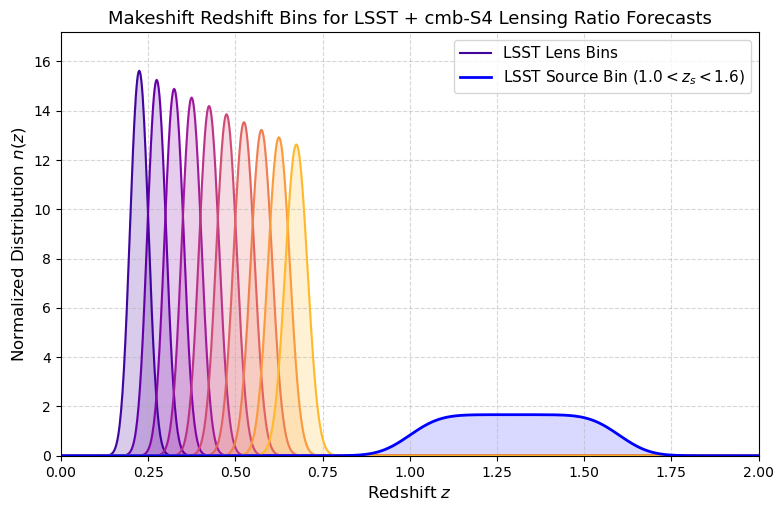

In [6]:
# create lens and source bins to be used for Prat check
# LSST + cmb-S4

# define redshift grid
z = np.linspace(0.0, 2.0, 1000)
dz = z[1] - z[0]

# build the 10 photometric lens bins (0.2 < z < 0.7) with equal number of galaxies
lens_edges = np.linspace(0.2, 0.7, 11)
lens_bins = []

# assume a redMaGiC-like photo-z scatter profile: \sigma_z = 0.0166 * (1 + z)
# "Such densities are comparable to what is currently achieved with DES redMaGiC"
# "the DES Y1 redMaGiC photo-zs have a scatter of σz = 0.0166(1 + z)"
for i in range(10):
    z_min, z_max = lens_edges[i], lens_edges[i+1]
    z_mid = (z_min + z_max) / 2.0

    # initialize nominal window
    top_hat = np.zeros_like(z)
    top_hat[(z >= z_min) & (z <= z_max)] = 1.0

    # Calculate pixel-level Gaussian smoothing representing photo-z scatter
    sigma = 0.0166 * (1 + z_mid)
    sigma_pix = sigma / dz

    # Convolve to get the realistic underlying true n(z) distribution
    nz_lens = gaussian_filter1d(top_hat, sigma_pix)

    # Normalize the distribution
    if np.sum(nz_lens) > 0:
        nz_lens /= np.sum(nz_lens) * dz
    lens_bins.append(nz_lens)

# build the single source bin (1.0 < z < 1.6)
source_min, source_max = 1.0, 1.6
source_mid = (source_min + source_max) / 2.0

top_hat_source = np.zeros_like(z)
top_hat_source[(z >= source_min) & (z <= source_max)] = 1.0

# LSST expected source sample photo-z scatter seems to be ~ \sigma_z = 0.03 * (1 + z)
# https://arxiv.org/pdf/2510.07370
sigma_src = 0.03 * (1 + source_mid)
sigma_src_pix = sigma_src / dz
nz_source = gaussian_filter1d(top_hat_source, sigma_src_pix)
nz_source /= np.sum(nz_source) * dz

# make into arrays
Prat_lens_data = np.column_stack([z] + lens_bins)
Prat_source_data = np.column_stack((z, nz_source))

# save data
np.save("data/Prat_lens_data", Prat_lens_data)
print("Saved Prat_lens_data to data/Prat_lens_data.npy")
np.save("data/Prat_source_data", Prat_source_data)
print("Saved Prat_source_data to data/Prat_source_data.npy")

# plot
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, 10))
z_plot = Prat_lens_data[:, 0]

for i in range(10):
    nz_plot = Prat_lens_data[:, i + 1]
    lbl = 'LSST Lens Bins' if i == 0 else ""
    ax.plot(z_plot, nz_plot, color=colors[i], lw=1.5, label=lbl)
    ax.fill_between(z_plot, nz_plot, color=colors[i], alpha=0.2)

ax.plot(Prat_source_data[:, 0], Prat_source_data[:, 1], color='blue', lw=2, label='LSST Source Bin ($1.0 < z_s < 1.6$)')
ax.fill_between(Prat_source_data[:, 0], Prat_source_data[:, 1], color='blue', alpha=0.15)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Normalized Distribution $n(z)$', fontsize=12)
ax.set_title('Makeshift Redshift Bins for LSST + cmb-S4 Lensing Ratio Forecasts', fontsize=13)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, max(np.max(lens_bins) * 1.1, np.max(nz_source) * 1.1))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

In [7]:
# build Prat cmb noise (TT, TE, EE)

SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_TT = SO_noise_data[:, 1]
N_TE = SO_noise_data[:, 2]
N_EE = SO_noise_data[:, 3]
Prat_ells_for_noise_interp = np.arange(30, 3000 + 30)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_TT_func = interp1d(S_noise_ells, N_TT, bounds_error=False, fill_value=(N_TT[0], N_TT[-1]))
Prat_cmb_noise_TT = interpolated_N_TT_func(Prat_ells_for_noise_interp)
interpolated_N_TE_func = interp1d(S_noise_ells, N_TE, bounds_error=False, fill_value=(N_TE[0], N_TE[-1]))
Prat_cmb_noise_TE = interpolated_N_TE_func(Prat_ells_for_noise_interp)
interpolated_N_EE_func = interp1d(S_noise_ells, N_EE, bounds_error=False, fill_value=(N_EE[0], N_EE[-1]))
Prat_cmb_noise_EE = interpolated_N_EE_func(Prat_ells_for_noise_interp)

np.save("data/Prat_cmb_noise_TT.npy", Prat_cmb_noise_TT)
print("Saved Prat_cmb_noise_TT to data/Prat_cmb_noise_TT.npy")
np.save("data/Prat_cmb_noise_TE.npy", Prat_cmb_noise_TE)
print("Saved Prat_cmb_noise_TE to data/Prat_cmb_noise_TE.npy")
np.save("data/Prat_cmb_noise_EE.npy", Prat_cmb_noise_EE)
print("Saved Prat_cmb_noise_EE to data/Prat_cmb_noise_EE.npy")

Saved Prat_cmb_noise_TT to data/Prat_cmb_noise_TT.npy
Saved Prat_cmb_noise_TE to data/Prat_cmb_noise_TE.npy
Saved Prat_cmb_noise_EE to data/Prat_cmb_noise_EE.npy


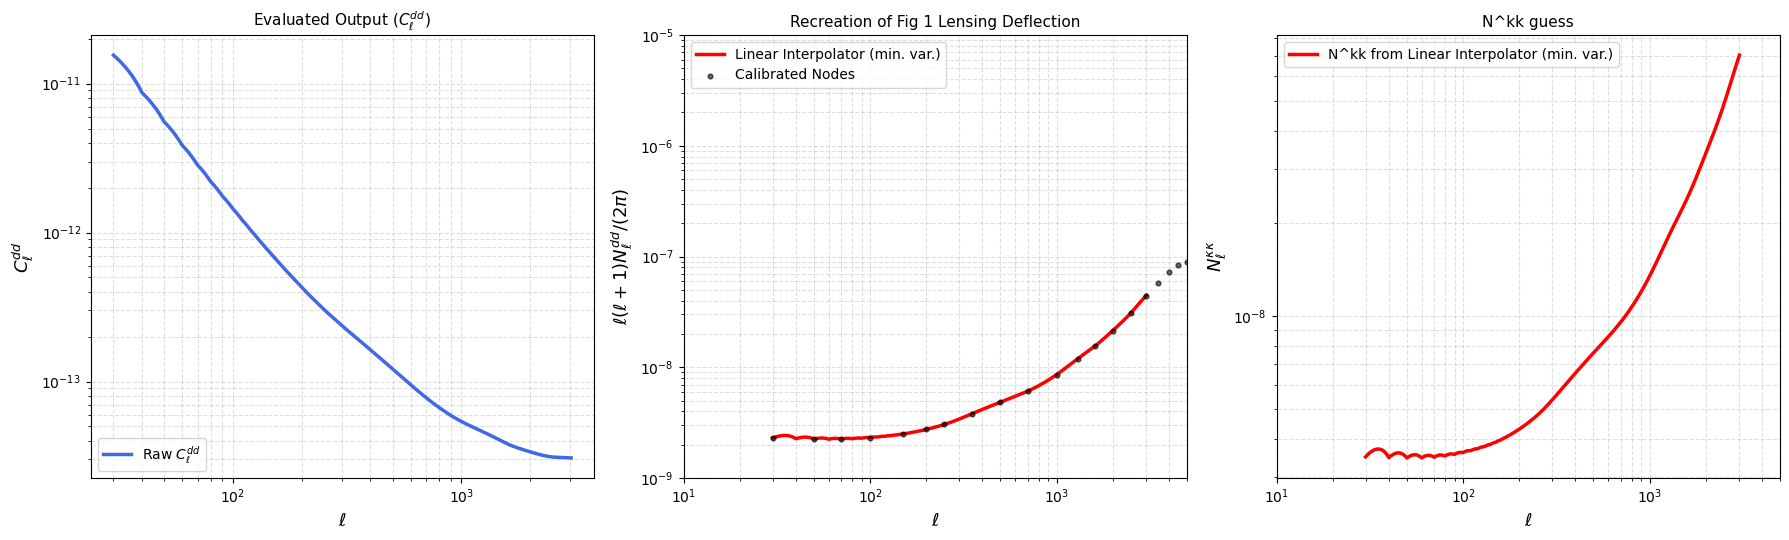

Saved Prat_cmb_noise_kk to data/Prat_cmb_noise_kk.npy


In [8]:
# cmb noise -- estimate from min variance graph, then map from N^dd to N^kk

# 1. High-precision nodes capturing the flat start, the mid-range bump, and the steep end
ell_nodes = np.array([
    30, 50, 70, 100, 150, 200, 250, 350, 500, 700, 1000,
    1300, 1600, 2000, 2500, 3000, 3500, 4000, 4500, 5000
])
scaled_nodes = np.array([
    2.30e-9, 2.25e-9, 2.25e-9, 2.32e-9,  # l=30 (start) -> shallow dip -> l=100
    2.50e-9, 2.75e-9, 3.05e-9, 3.80e-9,  # Gradual rise (l=200) -> shoulder/bump
    4.85e-9, 6.10e-9, 8.60e-9, 1.20e-8,  # l=500 slows -> l=700 -> l=1000 (<10^-8)
    1.55e-8, 2.15e-8, 3.10e-8, 4.40e-8,  # Steep rise past l=2000 -> l=3000
    5.80e-8, 7.30e-8, 8.40e-8, 9.00e-8   # Upper bounds -> terminates (<10^-7) at l=5000
])

ell_nodes = np.array([
    30, 50, 70, 100, 150, 200, 250, 350, 500, 700, 1000,
    1300, 1600, 2000, 2500, 3000, 3500, 4000, 4500, 5000
])
scaled_nodes = np.array([
    2.30e-9, 2.25e-9, 2.25e-9, 2.32e-9, 2.50e-9, 2.75e-9, 3.05e-9, 
    3.80e-9, 4.85e-9, 6.10e-9, 8.60e-9, 1.20e-8, 1.55e-8, 2.15e-8, 
    3.10e-8, 4.40e-8, 5.80e-8, 7.30e-8, 8.40e-8, 9.00e-8
])

cs_helper = CubicSpline(ell_nodes, scaled_nodes)
ell_base = np.linspace(30, 5000, 500)
scaled_base = cs_helper(ell_base)

# De-scale base values back to raw Cl^pp coordinates:
cl_dd_base = scaled_base * (2 * np.pi) / (ell_base * (ell_base + 1))

cl_dd_linear_interpolator = interp1d(
    ell_base, 
    cl_dd_base, 
    kind='linear', 
    bounds_error=False, 
    fill_value=0.0  # Fills anything outside [30, 5000] with 0
)

# Match your evaluation coordinates exactly to the target array
ell_array = Prat_ells_for_noise_interp  

# Evaluate directly in linear space
cl_dd_evaluated = cl_dd_linear_interpolator(ell_array)

# Calculate final physical scaling arrays
scaled_evaluated = ell_array * (ell_array + 1) * cl_dd_evaluated / (2 * np.pi)
Prat_n_kk = ell_array * (ell_array) * cl_dd_evaluated / 4
Prat_cmb_noise_kk = Prat_n_kk

# HARD MASK: Cleanly force any residual values below l=30 to be exactly 0.0
Prat_n_kk[ell_array < 30] = 0.0
scaled_evaluated[ell_array < 30] = 0.0

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# Left Panel: Pure Evaluated Raw Cl^pp
ax1.loglog(ell_array, cl_dd_evaluated, color='royalblue', lw=2.5, label=r'Raw $C_\ell^{dd}$')
ax1.set_xlabel(r'$\ell$', fontsize=13)
ax1.set_ylabel(r'$C_\ell^{dd}$', fontsize=13)
ax1.set_title(r'Evaluated Output ($C_\ell^{dd}$)', fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)
ax1.legend(loc='lower left')

# Middle Panel: Exact Mirror of Figure 1 Coordinates from arXiv:1607.01761
ax2.loglog(ell_array, scaled_evaluated, color='red', lw=2.5, label='Linear Interpolator (min. var.)')
ax2.scatter(ell_nodes, scaled_nodes, color='black', s=12, zorder=3, alpha=0.6, label='Calibrated Nodes')
ax2.set_xlim(10, 5000)
ax2.set_ylim(1e-9, 1e-5)
ax2.set_xlabel(r'$\ell$', fontsize=13)
ax2.set_ylabel(r'$\ell(\ell + 1) N_\ell^{dd} / (2\pi)$', fontsize=13)
ax2.set_title('Recreation of Fig 1 Lensing Deflection', fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)
ax2.legend(loc='upper left')

# Right Panel: N^kk_l
ax3.loglog(ell_array, Prat_n_kk, color='red', lw=2.5, label='N^kk from Linear Interpolator (min. var.)')
ax3.set_xlim(10, 5000)
ax3.set_xlabel(r'$\ell$', fontsize=13)
ax3.set_ylabel(r'$N_\ell^{\kappa\kappa}$', fontsize=13)
ax3.set_title('N^kk guess', fontsize=11)
ax3.grid(True, which='both', linestyle='--', alpha=0.4)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

np.save("data/Prat_cmb_noise_kk.npy", Prat_cmb_noise_kk)
print("Saved Prat_cmb_noise_kk to data/Prat_cmb_noise_kk.npy")

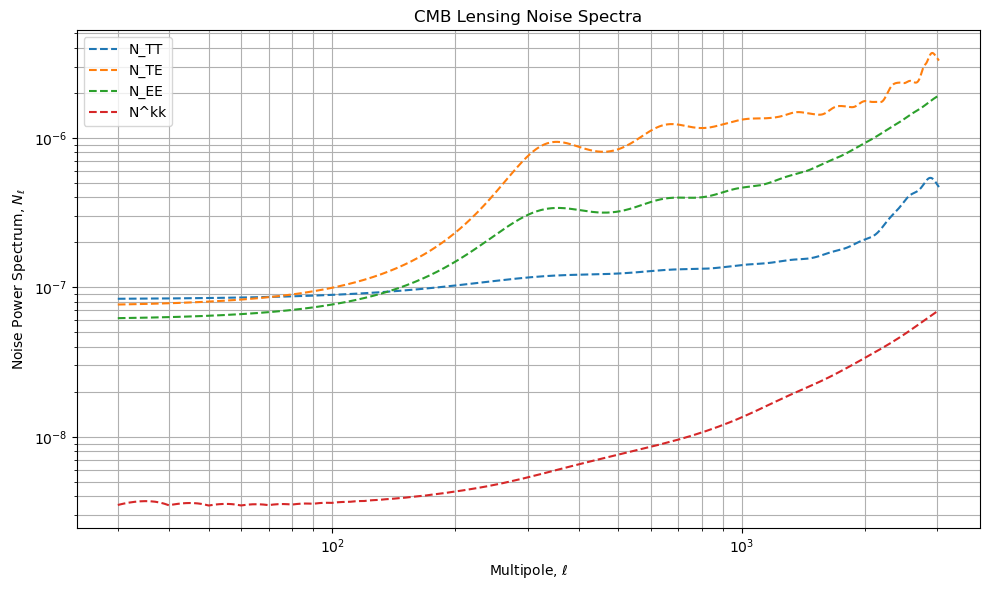

In [9]:
# plot cmb noise to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(Prat_ells_for_noise_interp, Prat_cmb_noise_TT, label='N_TT', linestyle='--')
plt.loglog(Prat_ells_for_noise_interp, Prat_cmb_noise_TE, label='N_TE', linestyle='--')
plt.loglog(Prat_ells_for_noise_interp, Prat_cmb_noise_EE, label='N_EE', linestyle='--')
plt.loglog(Prat_ells_for_noise_interp, Prat_cmb_noise_kk, label='N^kk', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}$')
plt.title('CMB Lensing Noise Spectra')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [10]:
# shot and shape noise
sigma = 0.26
Prat_n_bar_deg2 = np.array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100]) # Galaxies per square degree

# convert n_bar from per deg^2 to per steradian
Prat_n_bar_steradian = Prat_n_bar_deg2 * (180.0 / np.pi)**2

# Lens noise: 10 elements for 10 lens bins
Prat_shot_noise = 1.0 / Prat_n_bar_steradian

# Source noise: NumPy array with exactly 1 element for your single source bin
# (Using the first element of your conversion array as the baseline)
Prat_shape_noise = np.array([(sigma ** 2) / Prat_n_bar_steradian[0]])

np.save("data/Prat_shot_noise.npy", Prat_shot_noise)
np.save("data/Prat_shape_noise.npy", Prat_shape_noise)

## Prat Fisher Final

In [11]:
# Fisher forecast Prat recreation, sampling omega_b, omega_k, h, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min=30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_k', 'w0', 'Omega_b', 'h']
params_to_plot = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.378\pm 0.061$ | $\Omega_m = 0.38^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3089\pm 0.0018$ | $\Omega_m = 0.3089^{+0.0035}_{-0.0035}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3089\pm 0.0018$ | $\Omega_m = 0.3089^{+0.0035}_{-0.0035}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0093$ | $\Omega_k = 0.000^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0093$ | $\Omega_k = 0.000^{+0.018}_{-0.018}$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.078$ | $w_0 = -1.00^{+0.15}_{-0.15}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.9997\pm 0.078$ | $w_0 = -1.00^{+0.15}_{-0.15}$ |
| --- | --- | --- | --- |

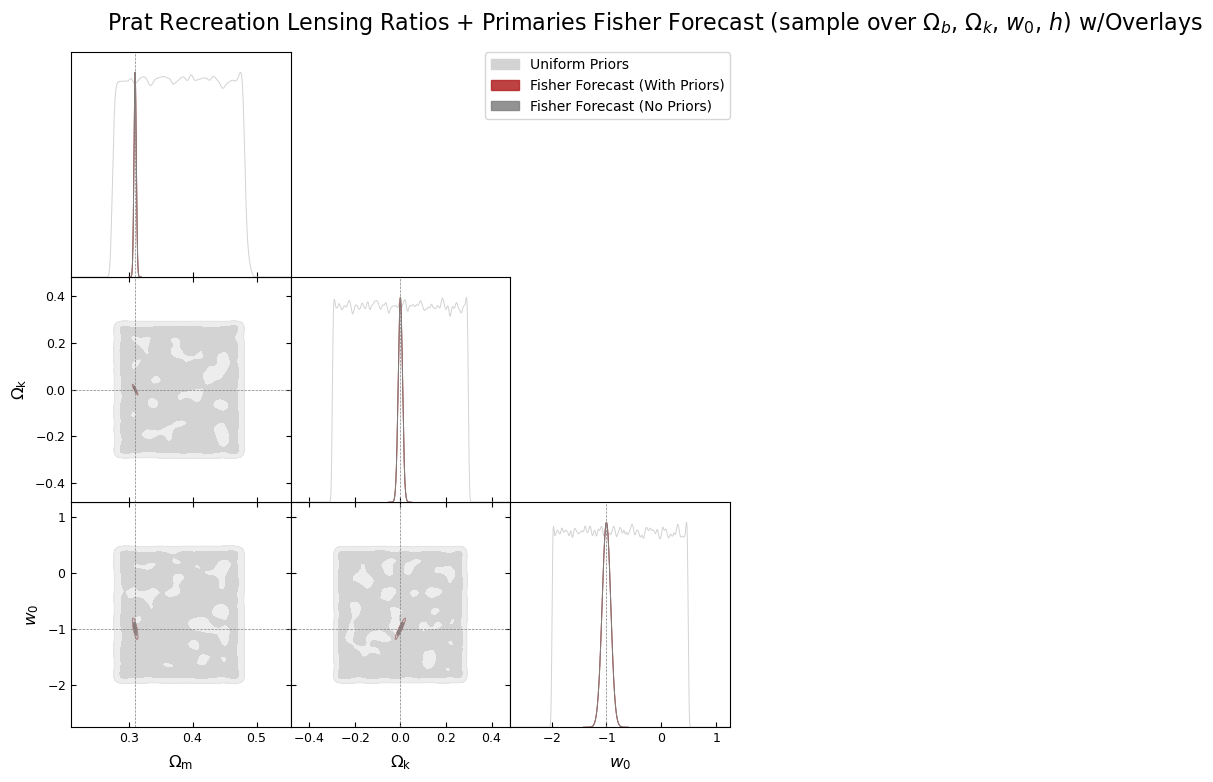

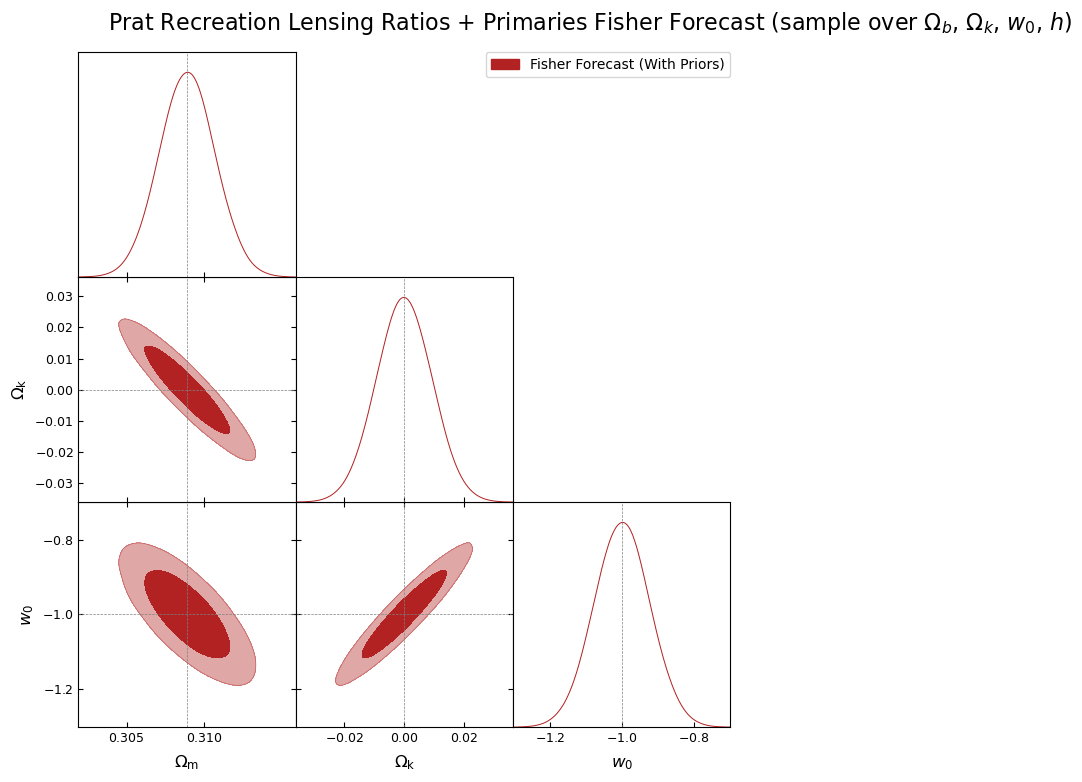

In [13]:
# Plot!

g = forecaster_c1.plot_with_cobaya_overlay(
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast (sample over $\Omega_b$, $\Omega_k$, $w_0$, $h$) w/Overlays",
    cobaya_chain_dir=None,
    plot_params=params_to_plot,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = True
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast (sample over $\Omega_b$, $\Omega_k$, $w_0$, $h$)",
    cobaya_chain_dir=None,
    plot_params=params_to_plot,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

plt.show()

## Prat MCMC

In [12]:
# calculate and save Prat fiducial data vector and covariance matrix w/lensing ratios primaries

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for Prat w/lensing ratios and primaries...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
l_min = 30
n_ell = 3000
binsize = 100
magnification_bias_lenses = None

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        Prat_lens_data,
        Prat_source_data,
        f_sky=f_sky,
        l_min=l_min,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=Prat_shot_noise,
        shape_noise_source=Prat_shape_noise,
        cmb_noise_kk=Prat_cmb_noise_kk,
        cmb_noise_TT=Prat_cmb_noise_TT,
        cmb_noise_EE=Prat_cmb_noise_EE,
        cmb_noise_TE=Prat_cmb_noise_TE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=['CG', 'GL', 'EE', 'TT', 'TE'],
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries = True,
        z_max = 6,
        n_chi = 1024
    )

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/Prat_data_vector.npy'
covariance_filename = 'cobaya_data/Prat_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

Calculating fiducial data vector and covariance matrix for Prat w/lensing ratios and primaries...


In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/Prat_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
CHAIN_DEST="chains/Prat_likelihood"
mkdir -p $CHAIN_DEST

for i in {0..3}; do
    cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt $CHAIN_DEST/chain_task_${i}.txt
    ln -sf chain_task_${i}.txt $CHAIN_DEST/cosmo_run.${i}.txt
done

# Copy the paramnames file so your plotting code works immediately
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/chain_task.paramnames
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/cosmo_run.paramnames

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/Prat_likelihood.yaml
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/Prat_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/Prat_triangle_plot_(incomplete).pdf


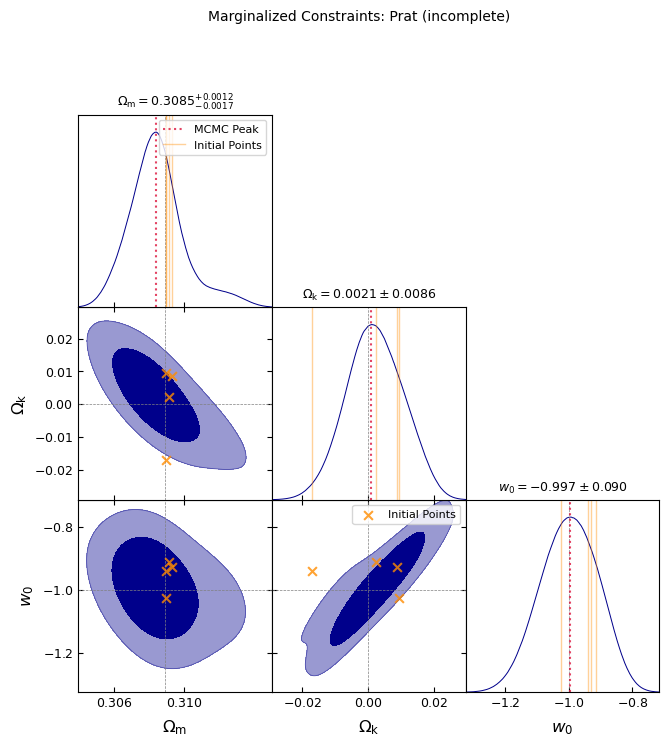

Saved trace plot to: plots/MCMC_runs/traces_and_dists/Prat_traces_(incomplete).png


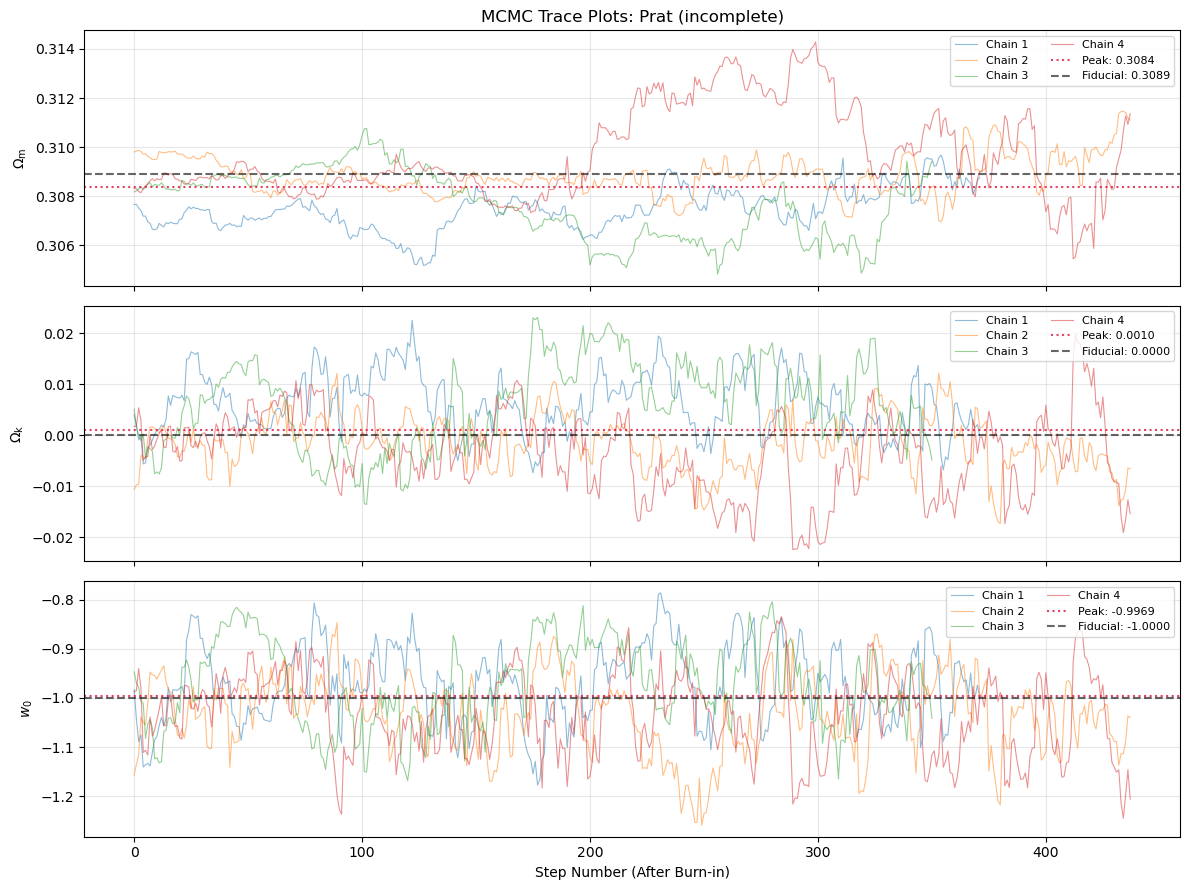

| Parameter | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :---: | :---: |
| **$\Omega_\mathrm{m}$** | $\Omega_\mathrm{m} = 0.3085^{+0.0012}_{-0.0017}$ | $\Omega_\mathrm{m} = 0.3085^{+0.0036}_{-0.0032}$ |
| --- | --- | --- |
| **$\Omega_\mathrm{k}$** | $\Omega_\mathrm{k} = 0.0021\pm 0.0086$ | $\Omega_\mathrm{k} = 0.002^{+0.016}_{-0.017}$ |
| --- | --- | --- |
| **$w_0$** | $w_0 = -0.997\pm 0.090$ | $w_0 = -0.997^{+0.16}_{-0.17}$ |
| --- | --- | --- |



Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/Prat_likelihood.yaml
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/Prat_likelihood


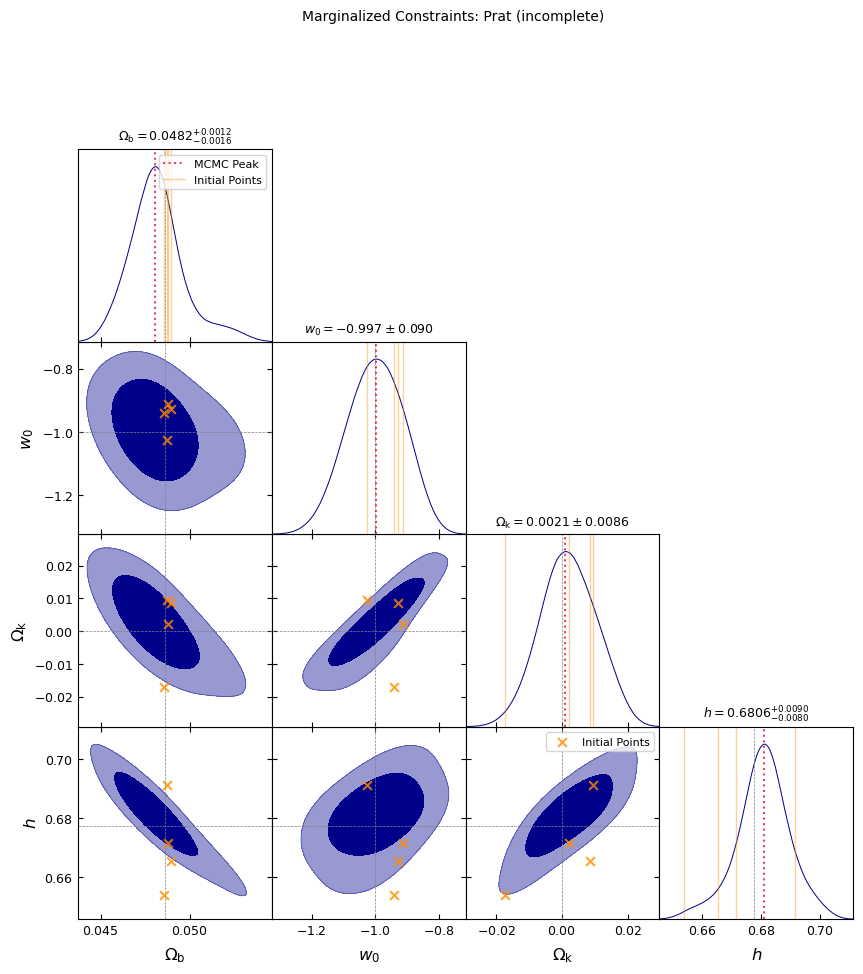

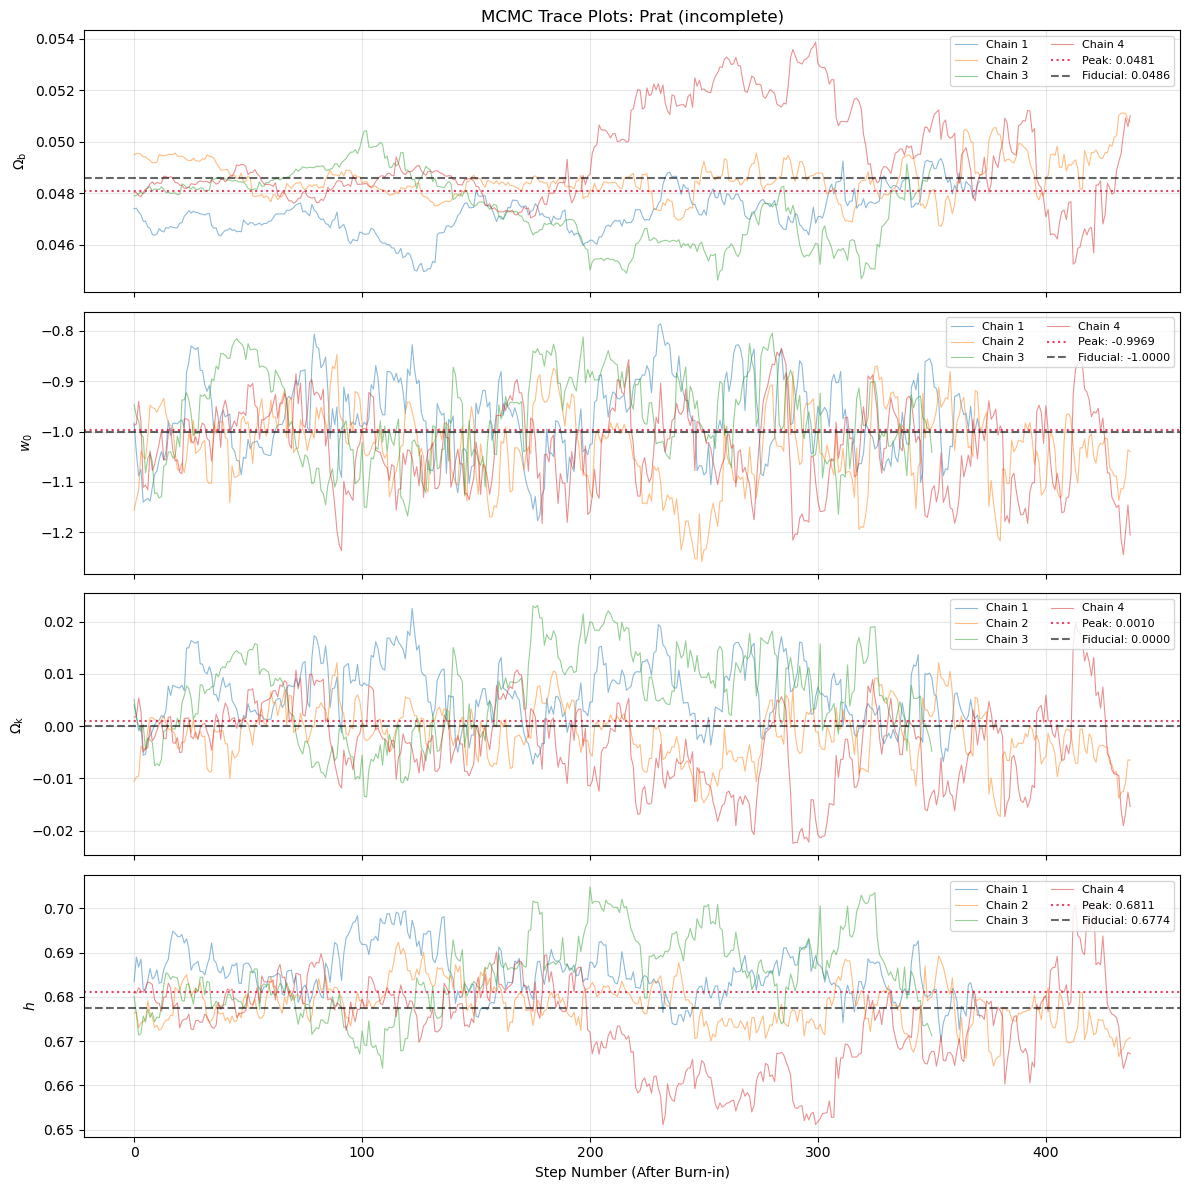

| Parameter | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :---: | :---: |
| **$\Omega_\mathrm{b}$** | $\Omega_\mathrm{b} = 0.0482^{+0.0012}_{-0.0016}$ | $\Omega_\mathrm{b} = 0.0482^{+0.0036}_{-0.0031}$ |
| --- | --- | --- |
| **$w_0$** | $w_0 = -0.997\pm 0.090$ | $w_0 = -0.997^{+0.16}_{-0.17}$ |
| --- | --- | --- |
| **$\Omega_\mathrm{k}$** | $\Omega_\mathrm{k} = 0.0021\pm 0.0086$ | $\Omega_\mathrm{k} = 0.002^{+0.016}_{-0.017}$ |
| --- | --- | --- |
| **$h$** | $h = 0.6806^{+0.0090}_{-0.0080}$ | $h = 0.681^{+0.020}_{-0.023}$ |
| --- | --- | --- |

In [11]:
# plot results for flat_LCDM_bin1_LRP_omega_b_omega_c_likelihood -- first test of new derived paramter strategy
# parameters_to_sample must be given in the same order in which they were given in the yaml file

# Define your environment paths
chain_folder = os.path.expanduser('~/DESIxSO/chains/Prat_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/Prat_likelihood.yaml'
params_to_sample = ['Omega_b', 'w0', 'Omega_k', 'h']
params_to_plot = ['Omega_m', 'Omega_k', 'w0']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_to_sample,
    plot_params=params_to_plot,
    num_chains=4,
    burn_in_fraction=0.4,
    plot_triangle=True,
    plot_traces=True,
    save_triangle=True,
    save_traces=True,
    print_summary=True,
    complete=False,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_to_sample,
    plot_params=params_to_sample,
    num_chains=4,
    burn_in_fraction=0.4,
    plot_triangle=True,
    plot_traces=True,
    save_triangle=False,
    save_traces=False,
    print_summary=True,
    complete=False,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

## Prat Fisher Tests

In [ ]:
# Fisher forecast with five params -- omega_m, omega_k, omega_b, h, w0
# DO NOT RERUN THESE, THE CLASS WILL NO LONGER SUPPORT THIS

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.350\pm 0.089$ | $\Omega_m = 0.35^{+0.18}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.112$ | $\Omega_m = 0.307 \pm 0.225$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = -0.003\pm 0.049$ | $\Omega_k = -0.003^{+0.096}_{-0.098}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.053$ | $\Omega_k = 0.000 \pm 0.106$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.82\pm 0.54$ | $w_0 = -0.8^{+1.0}_{-1.0}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.662$ | $w_0 = -1.000 \pm 1.324$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.73^{+0.21}_{-0.12}$ | $h = 0.73^{+0.27}_{-0.28}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.289$ | $h = 0.677 \pm 0.577$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.080^{+0.021}_{-0.067}$ | $\Omega_b = 0.080^{+0.085}_{-0.069}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.092$ | $\Omega_b = 0.049 \pm 0.184$ |
| --- | --- | --- | --- |

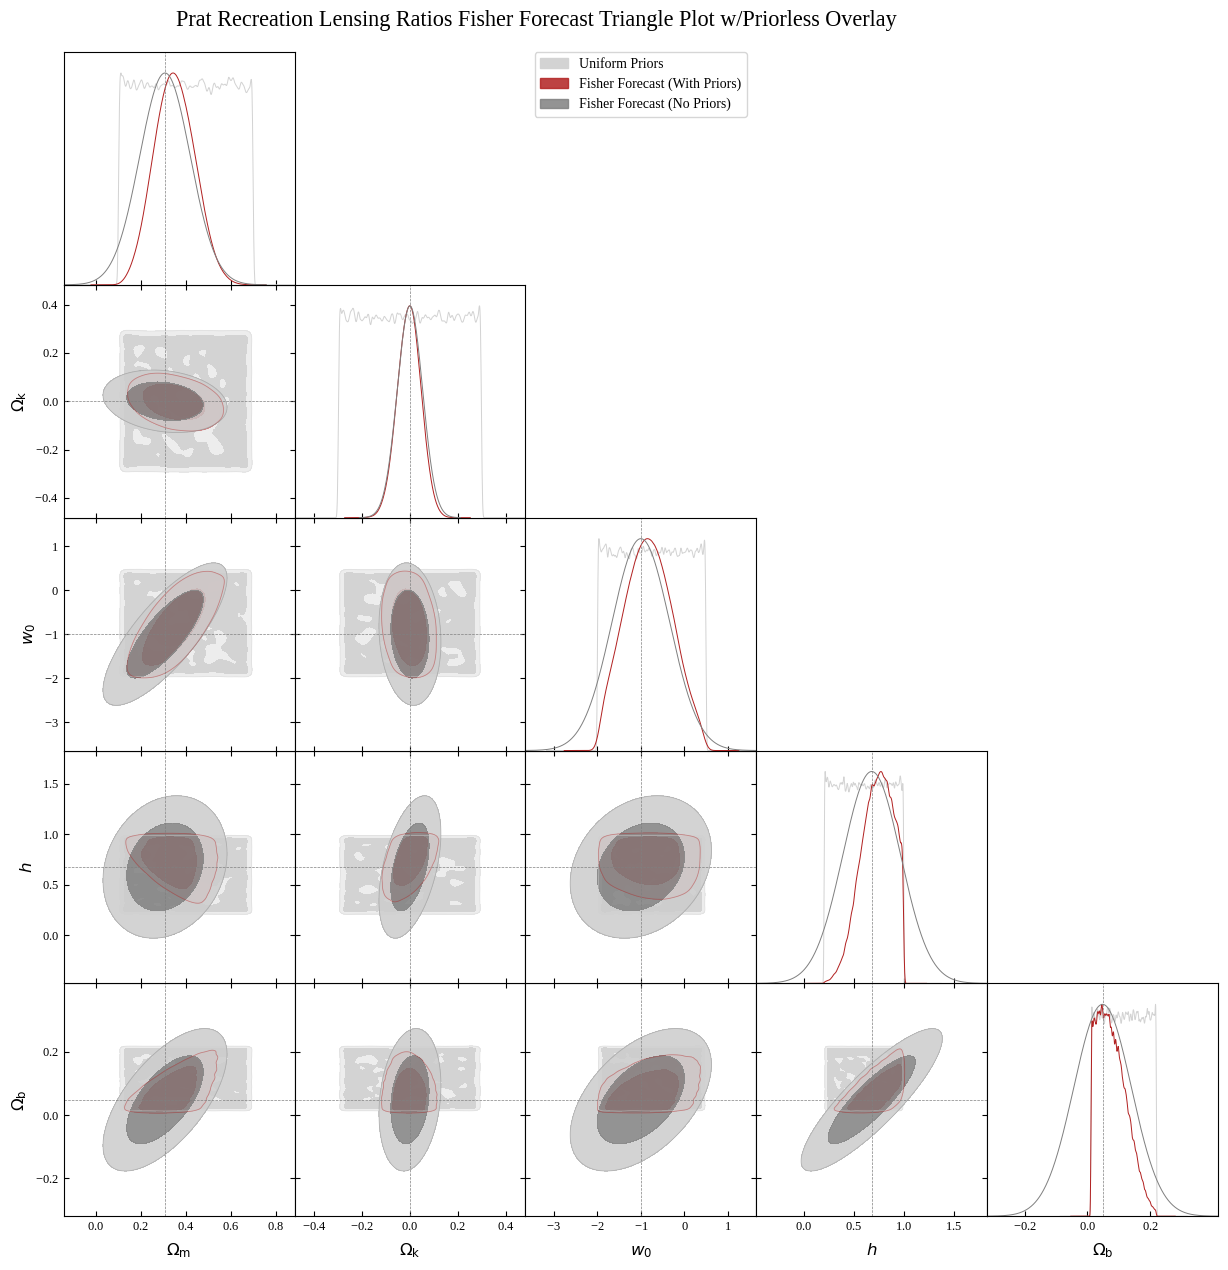

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


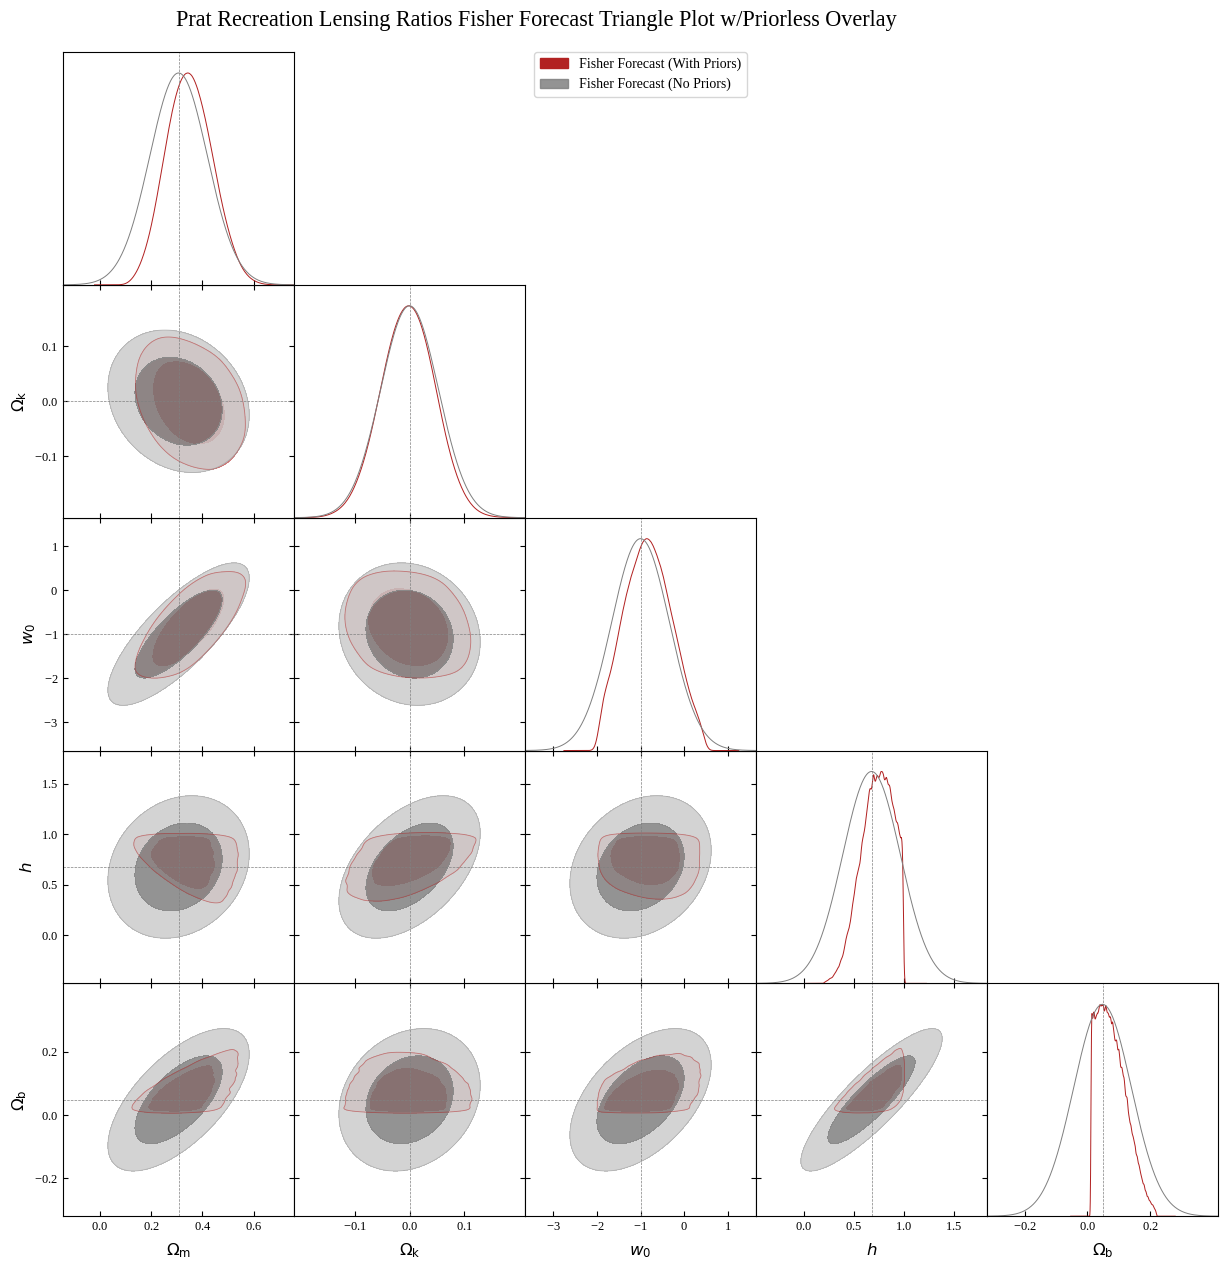

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot.pdf


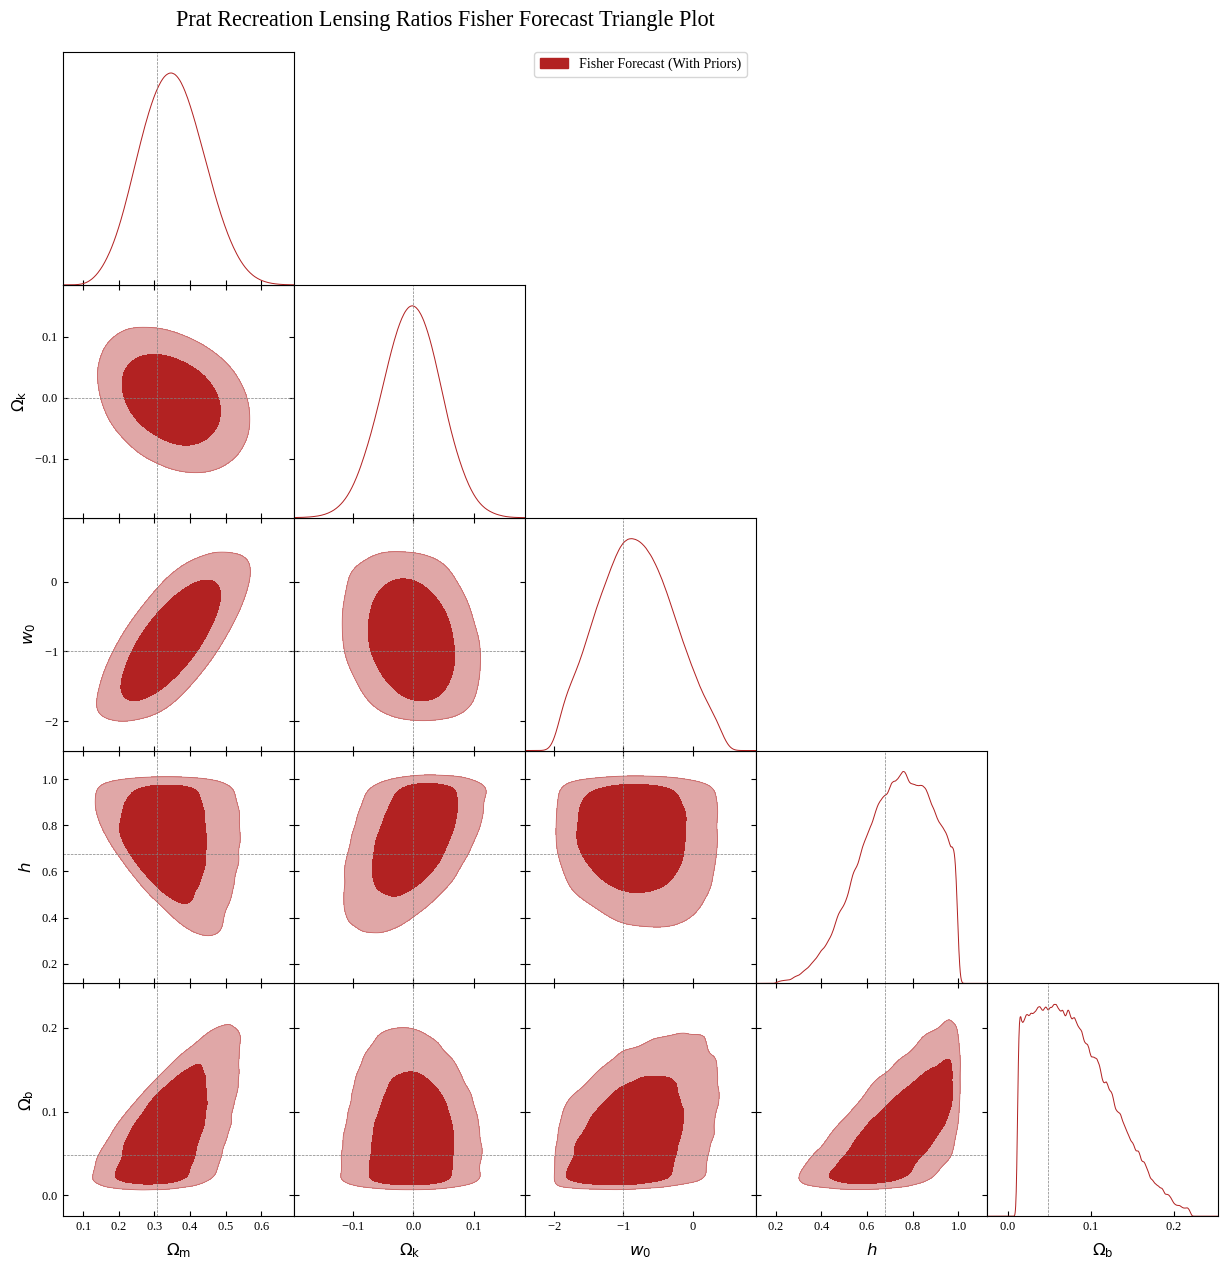

In [30]:
# Fisher forecast w/o primaries w/five params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'h', 'Omega_b']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.36^{+0.11}_{-0.21}$ | $\Omega_m = 0.36^{+0.27}_{-0.25}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.216$ | $\Omega_m = 0.307 \pm 0.432$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = -0.004^{+0.018}_{-0.016}$ | $\Omega_k = -0.004^{+0.030}_{-0.033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.021$ | $\Omega_k = 0.000 \pm 0.043$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.89^{+0.31}_{-0.44}$ | $w_0 = -0.89^{+0.68}_{-0.62}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.501$ | $w_0 = -1.000 \pm 1.002$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.116^{+0.10}_{-0.099}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.056^{+0.017}_{-0.033}$ | $\Omega_b = 0.056^{+0.044}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.034$ | $\Omega_b = 0.049 \pm 0.068$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.62^{+0.23}_{-0.12}$ | $h = 0.62^{+0.28}_{-0.30}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.239$ | $h = 0.677 \pm 0.477$ |
| --- | --- | --- | --- |

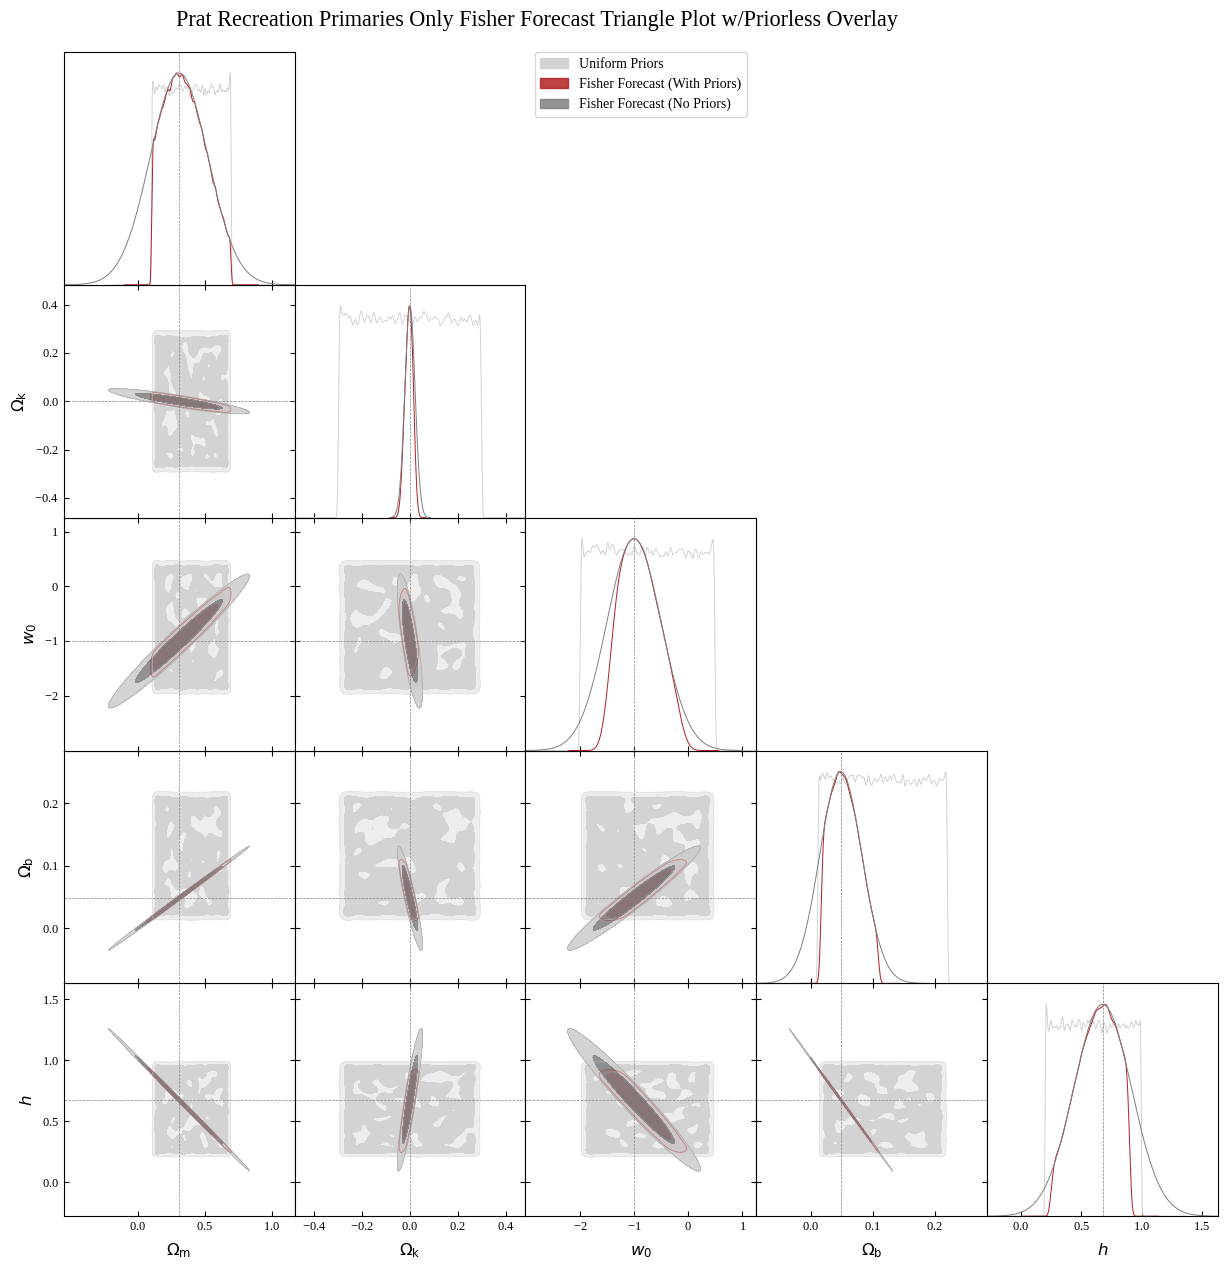

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


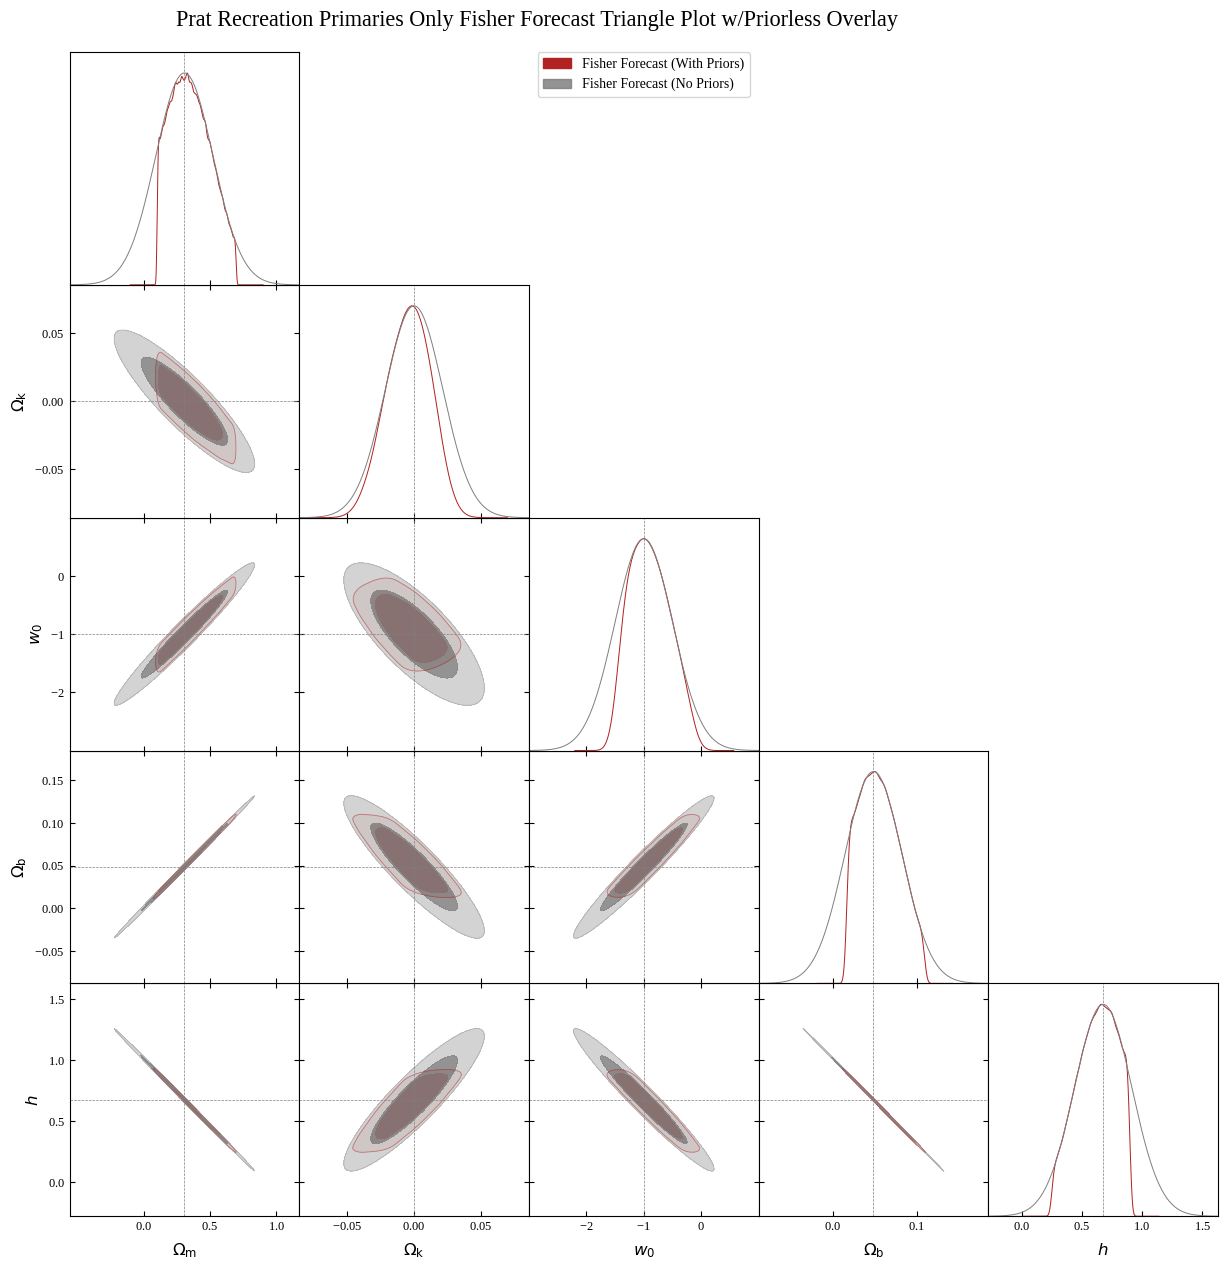

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot.pdf


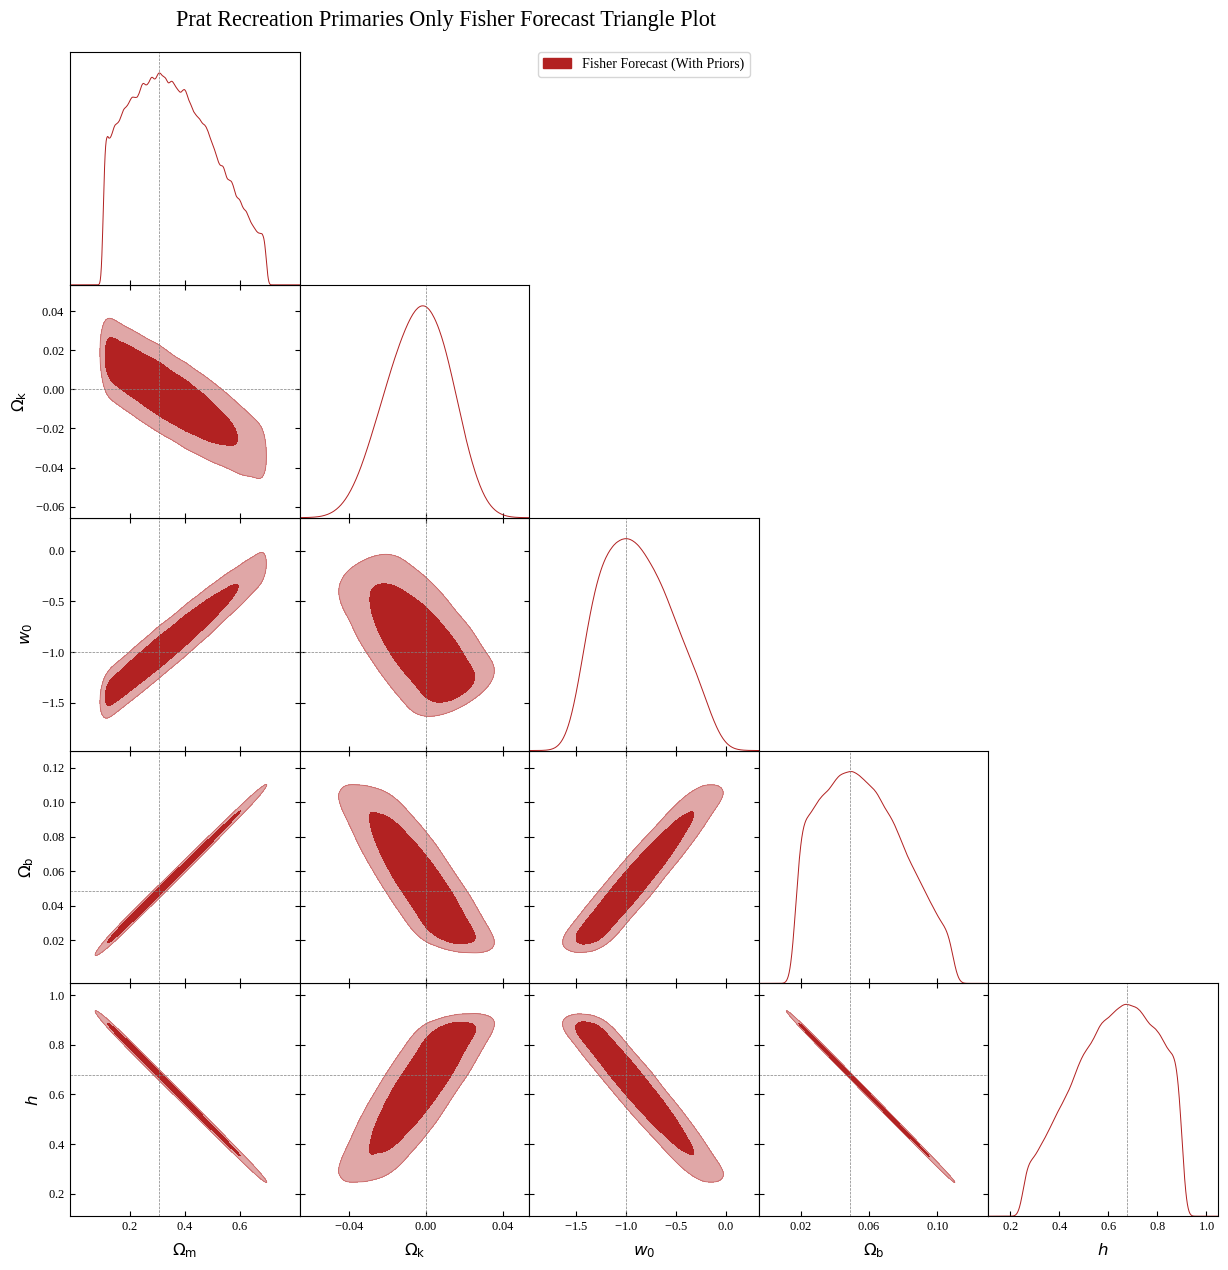

In [31]:
# Fisher forecast w/primaries ONLY (five params)

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.308\pm 0.075$ | $\Omega_m = 0.31^{+0.15}_{-0.15}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.076$ | $\Omega_m = 0.307 \pm 0.153$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.000\pm 0.011$ | $\Omega_k = 0.000^{+0.022}_{-0.022}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.011$ | $\Omega_k = 0.000 \pm 0.022$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.998\pm 0.20$ | $w_0 = -0.998^{+0.40}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.204$ | $w_0 = -1.000 \pm 0.408$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.049\pm 0.012$ | $\Omega_b = 0.049^{+0.024}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.012$ | $\Omega_b = 0.049 \pm 0.024$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.677\pm 0.084$ | $h = 0.68^{+0.16}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.085$ | $h = 0.677 \pm 0.170$ |
| --- | --- | --- | --- |

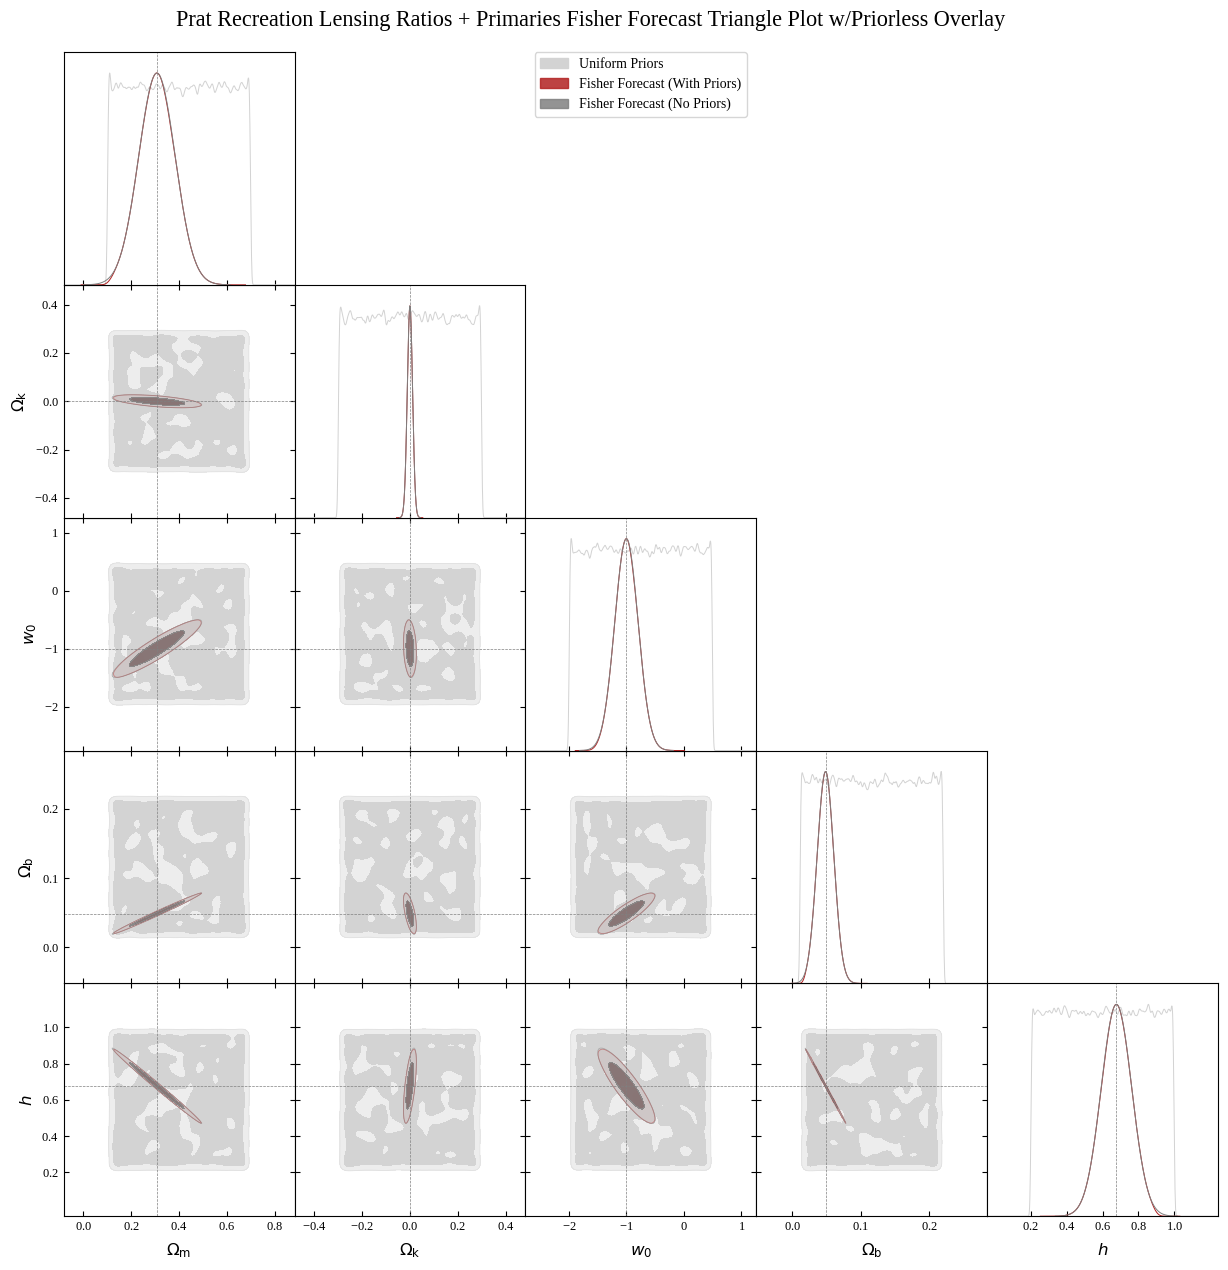

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


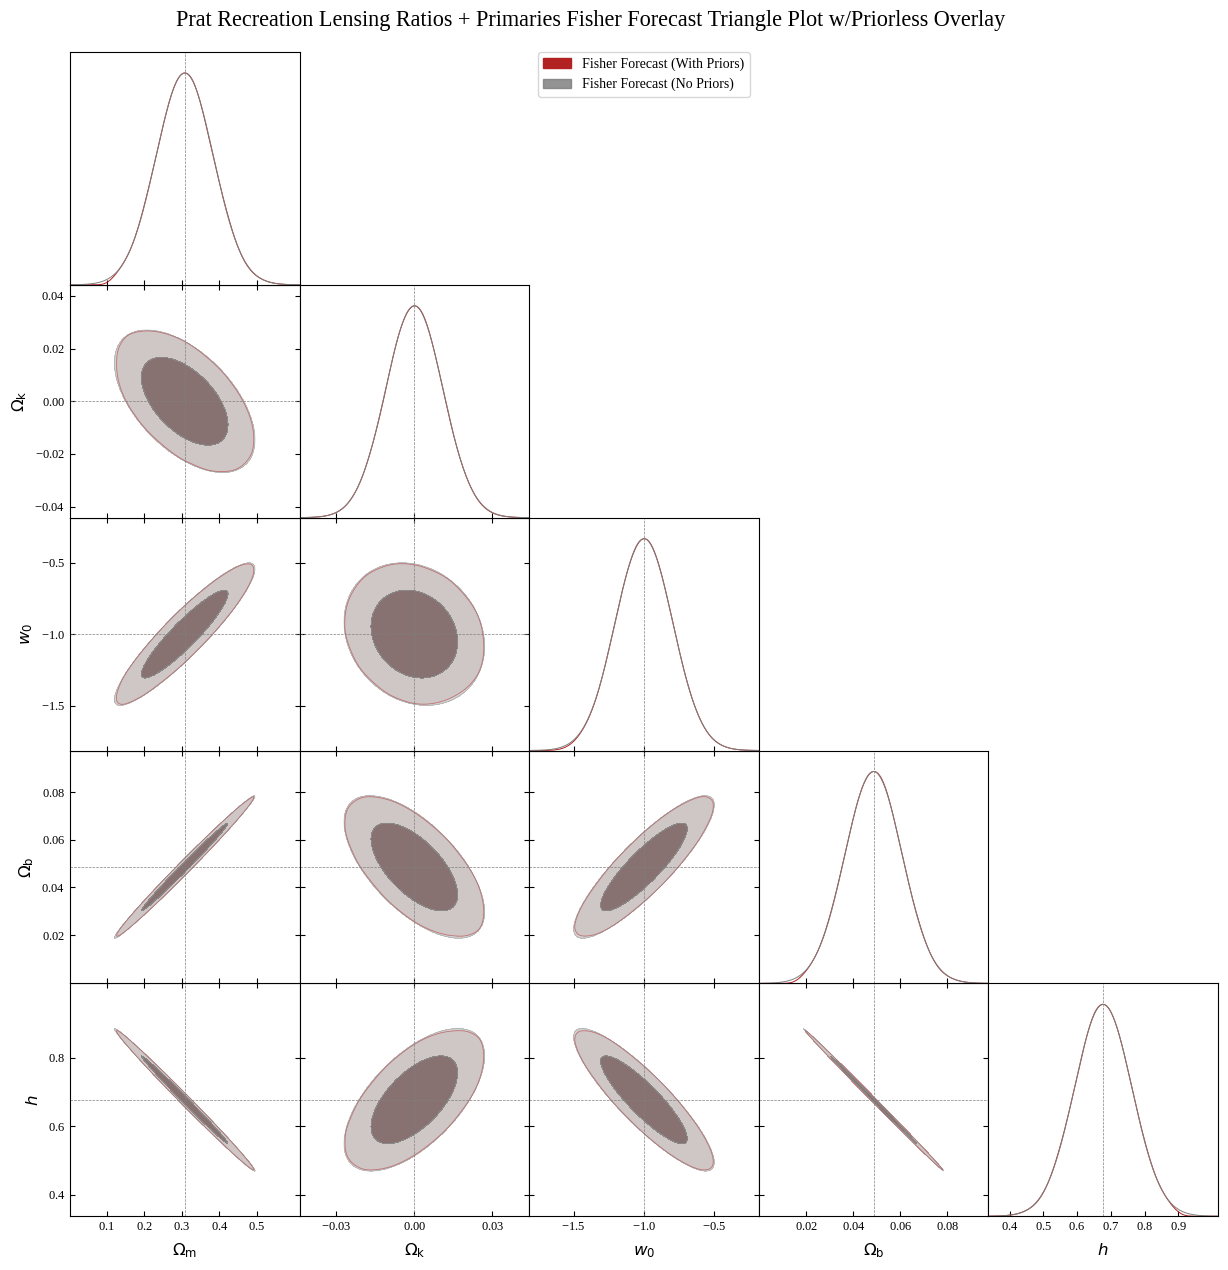

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


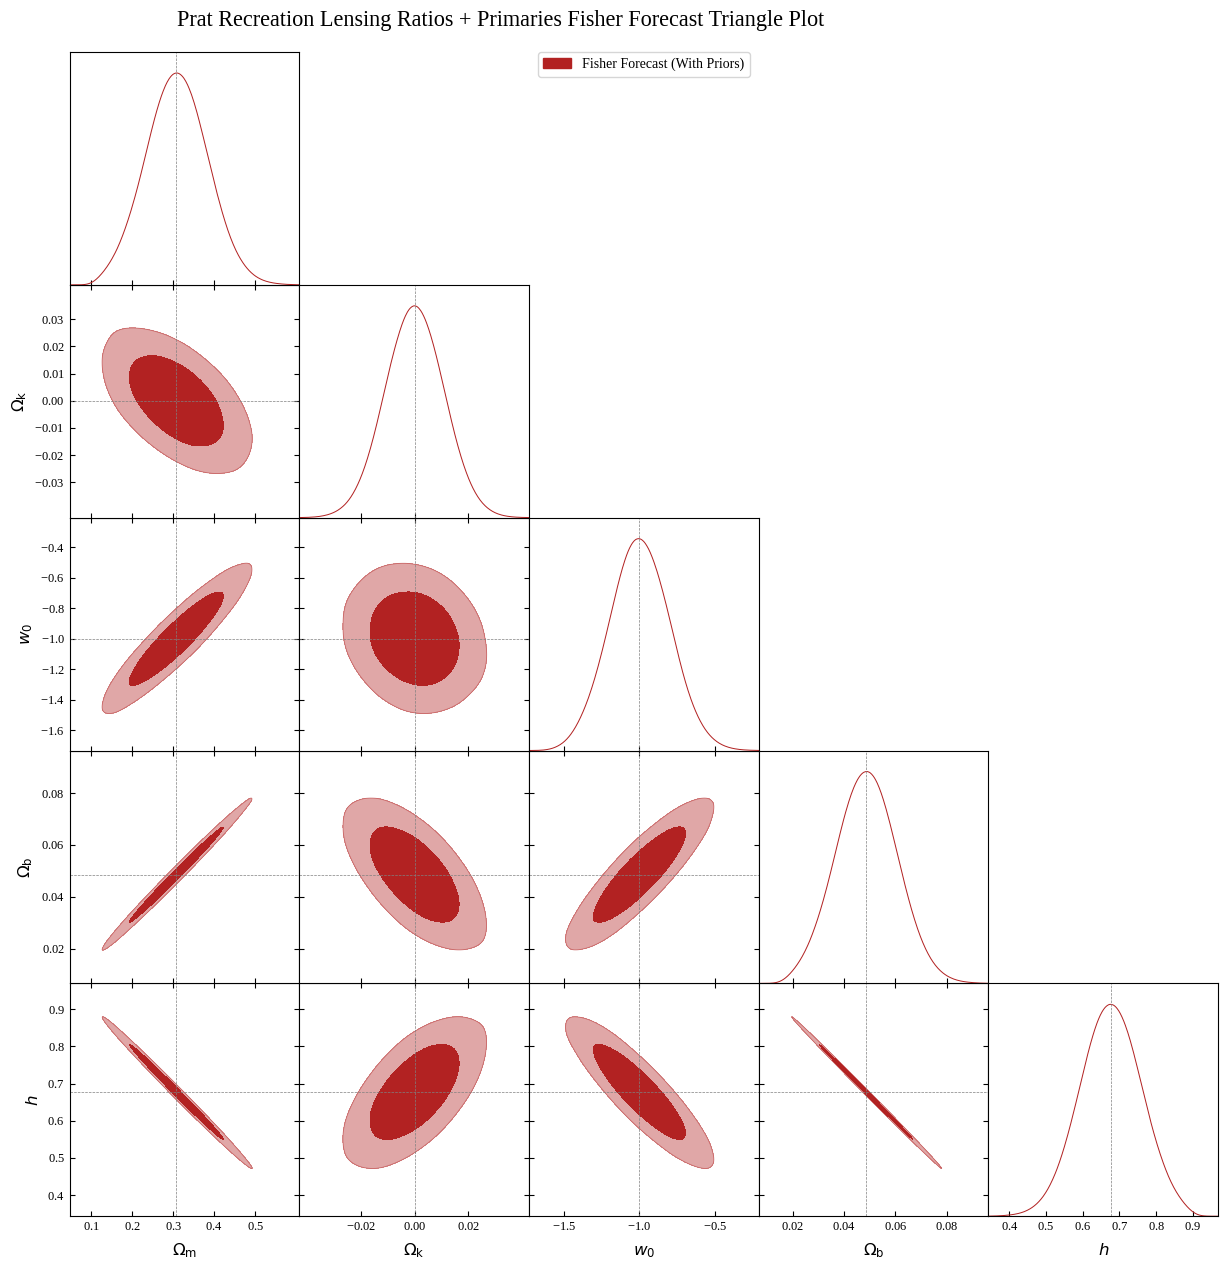

In [32]:
# Fisher forecast w/lensing ratios and primaries and five params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [ ]:
## Fisher with four params -- omega_k, w0, h, omega_b and/or omega_c
# This was me trying to figure out the contributions of different parameters on omega_m

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.0486\pm 0.0015$ | $\Omega_b = 0.0486^{+0.0029}_{-0.0029}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.0486 \pm 0.0015$ | $\Omega_b = 0.0486 \pm 0.0030$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.28}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0091$ | $\Omega_k = 0.000^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0091$ | $\Omega_k = 0.000 \pm 0.018$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.9998\pm 0.080$ | $w_0 = -1.00^{+0.16}_{-0.16}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.080$ | $w_0 = -1.000 \pm 0.161$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0083$ | $h = 0.677^{+0.016}_{-0.016}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0083$ | $h = 0.677 \pm 0.017$ |
| --- | --- | --- | --- |

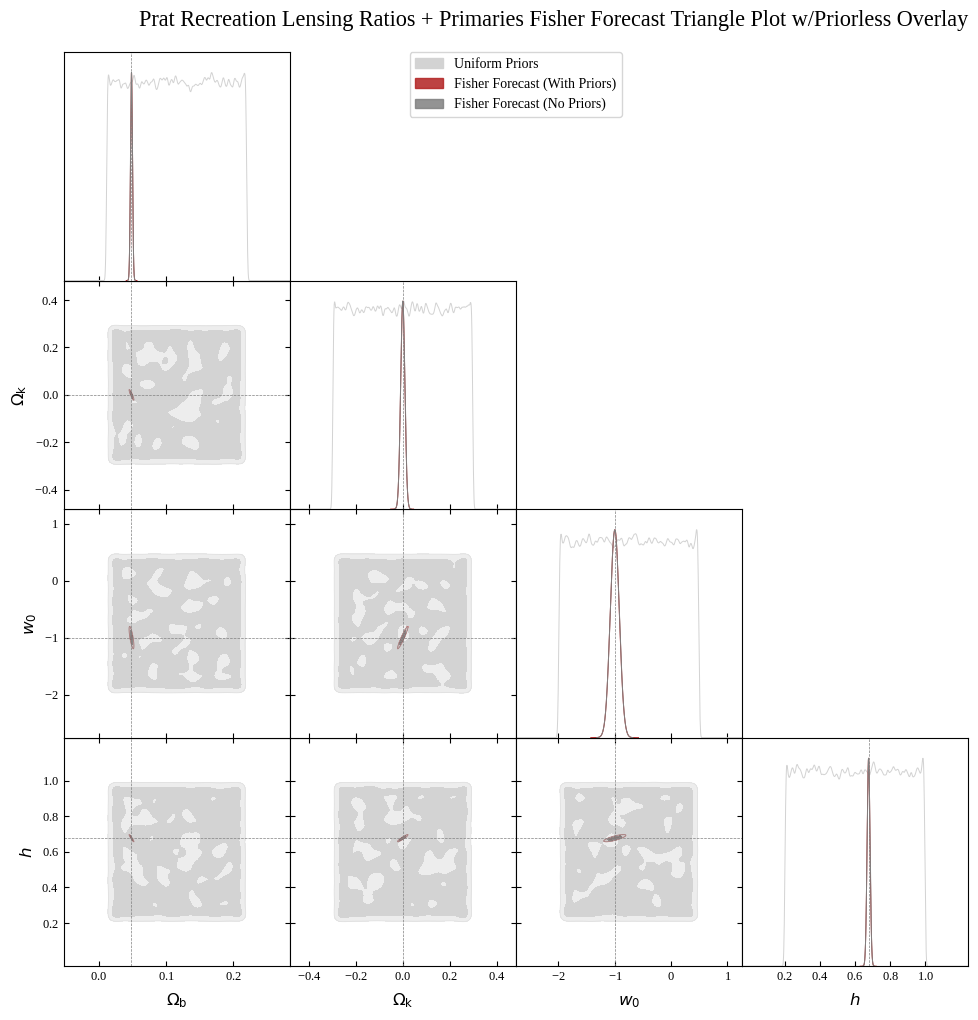

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


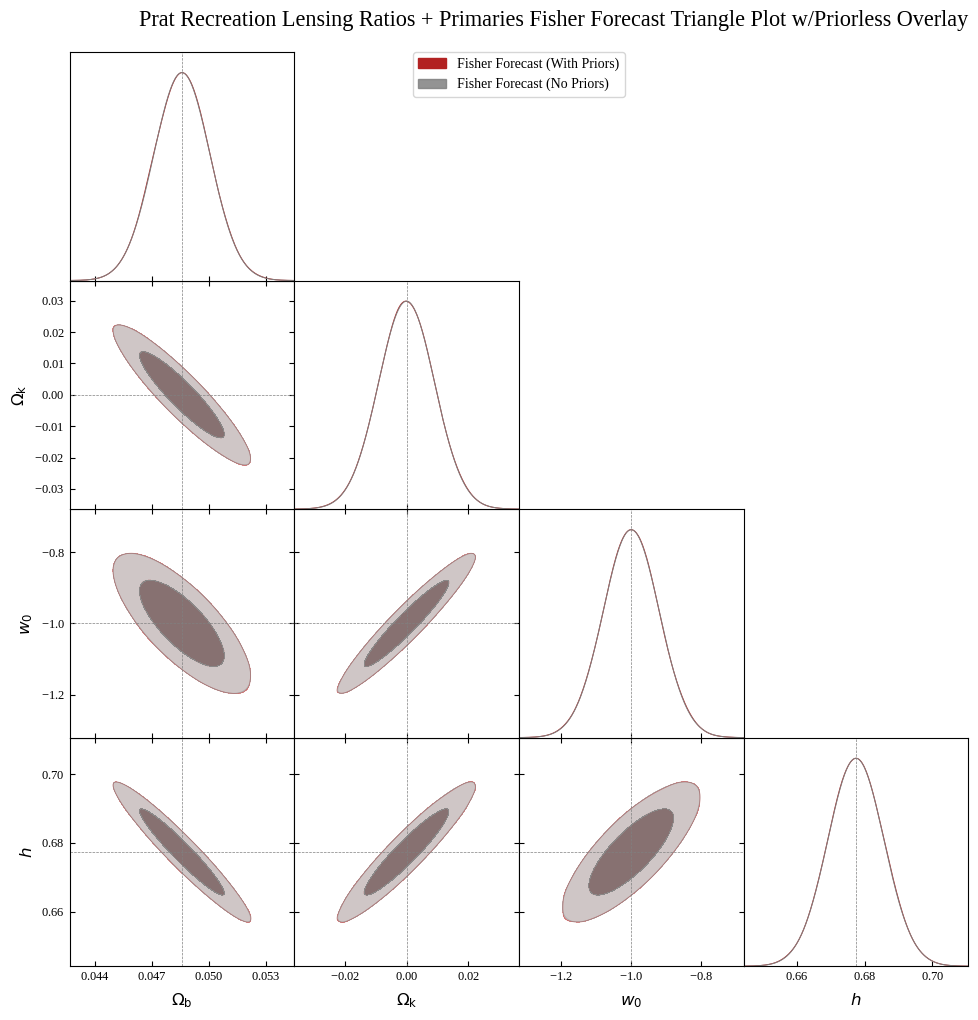

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


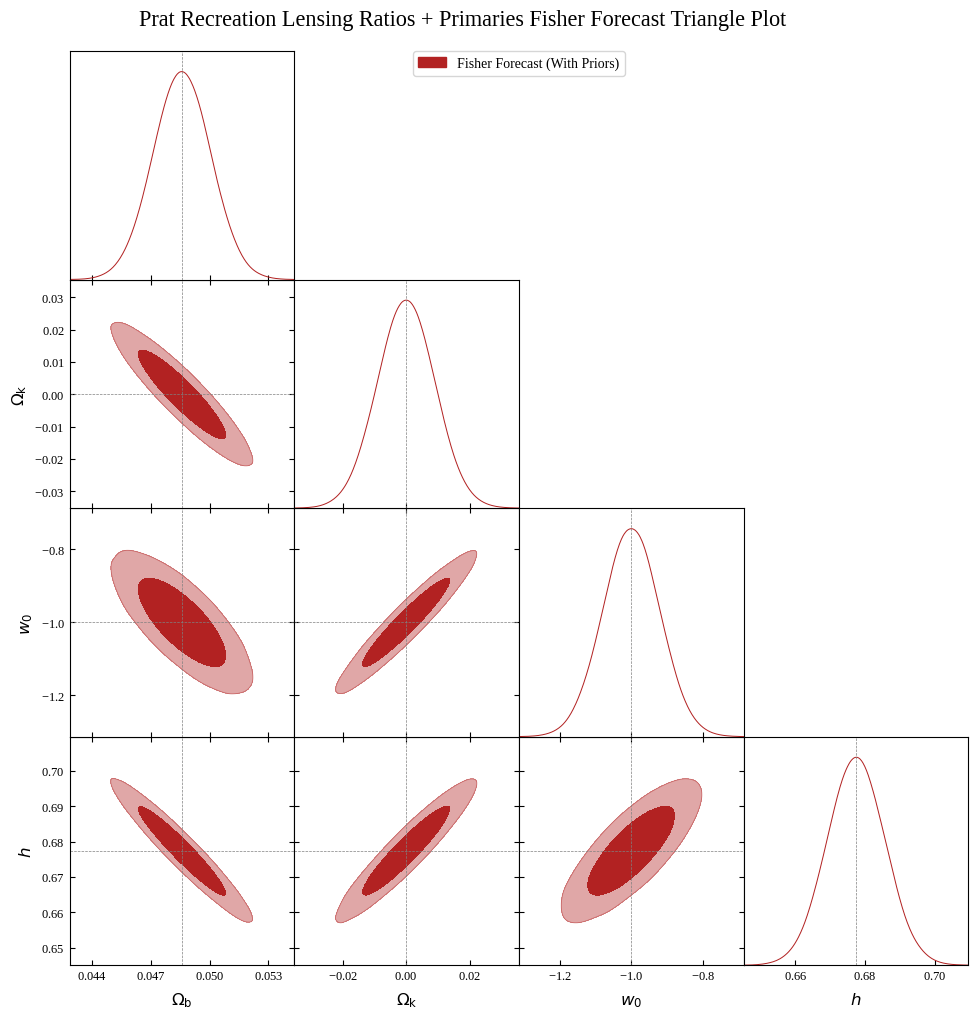

In [24]:
# Fisher forecast w/lensing ratios and primaries and four params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_b', 'Omega_k', 'w0', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_c$** | Uniform Priors | $\Omega_c = 0.250\pm 0.087$ | $\Omega_c = 0.25^{+0.14}_{-0.14}$ |
|  | Fisher Forecast (With Priors) | $\Omega_c = 0.2589\pm 0.0086$ | $\Omega_c = 0.259^{+0.017}_{-0.017}$ |
|  | Fisher Forecast (No Priors) | $\Omega_c = 0.2589 \pm 0.0086$ | $\Omega_c = 0.259 \pm 0.017$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0080$ | $\Omega_k = 0.000^{+0.016}_{-0.016}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0080$ | $\Omega_k = 0.000 \pm 0.016$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.094$ | $w_0 = -1.00^{+0.18}_{-0.19}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.094$ | $w_0 = -1.000 \pm 0.189$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0033$ | $h = 0.6774^{+0.0065}_{-0.0065}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0033$ | $h = 0.6774 \pm 0.0067$ |
| --- | --- | --- | --- |

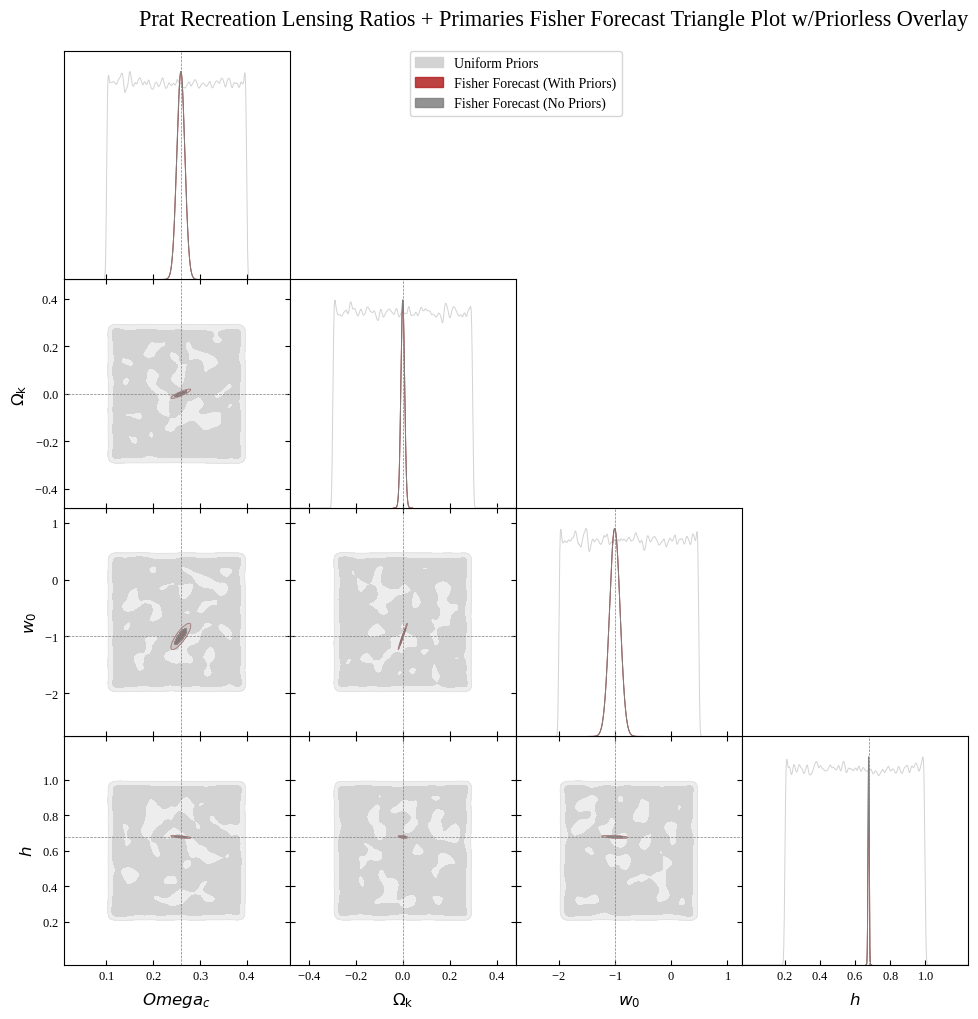

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


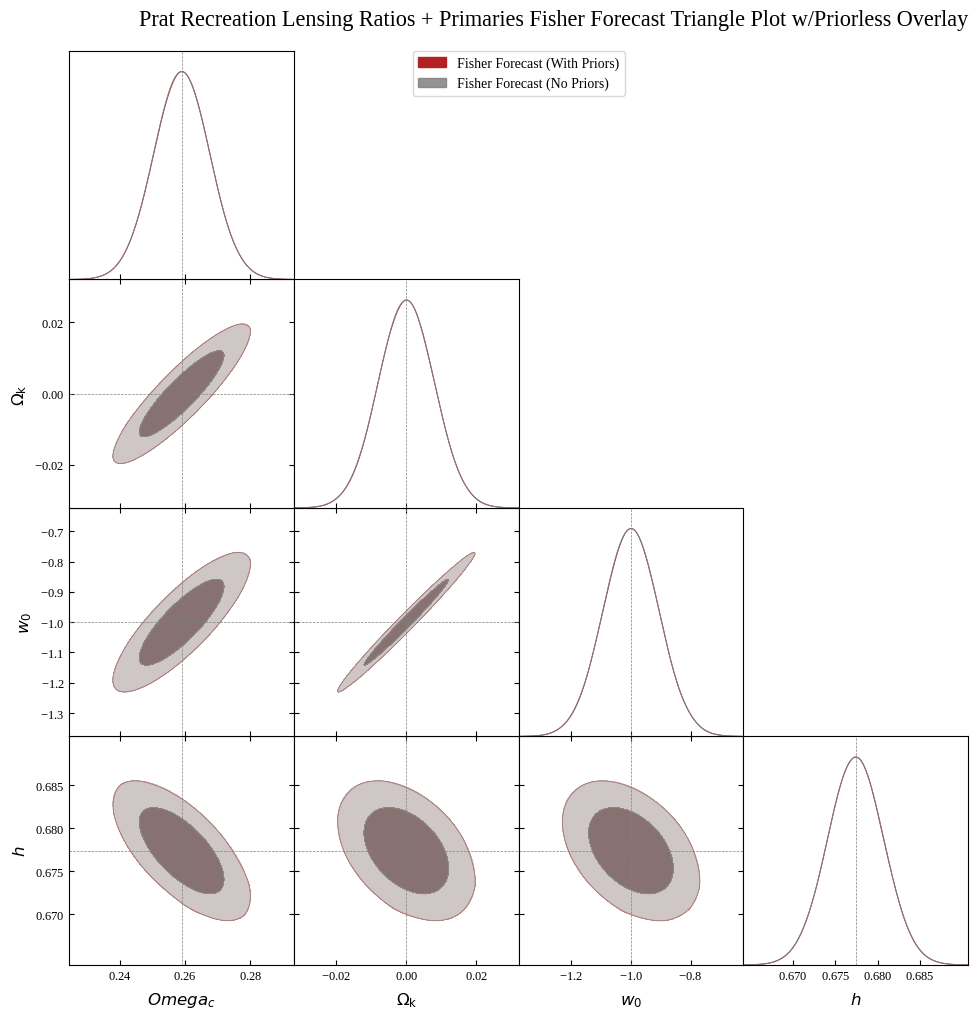

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


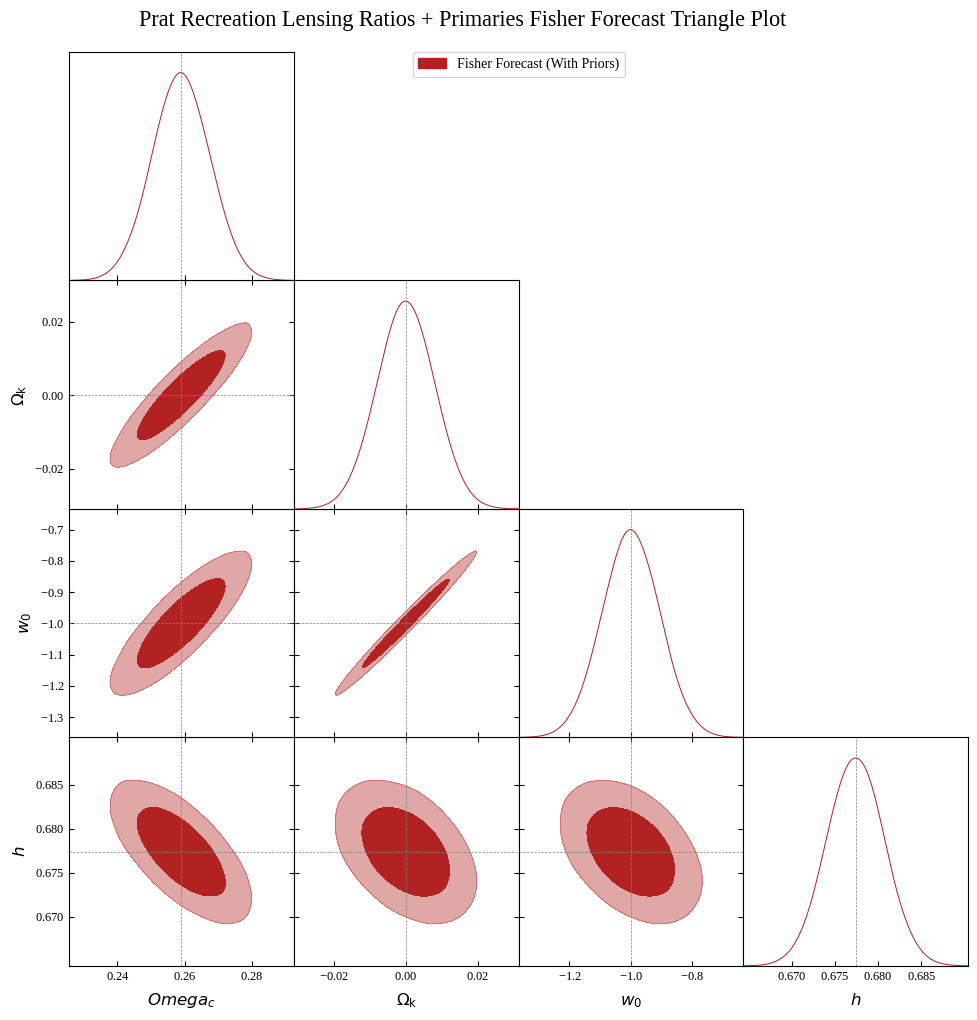

In [22]:
# Fisher forecast w/lensing ratios and primaries and four params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_c': (0.1, 0.4)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_c', 'Omega_k', 'w0', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [ ]:
## Fisher with four params -- three plotted, plus h OR omega_b 
# This was me trying to figure out the impact of the hidden parameters on the degeneracy directions

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0093$ | $\Omega_m = 0.307^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0093$ | $\Omega_m = 0.307 \pm 0.019$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0084$ | $\Omega_k = 0.000^{+0.016}_{-0.016}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0084$ | $\Omega_k = 0.000 \pm 0.017$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.098$ | $w_0 = -1.00^{+0.19}_{-0.19}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.098$ | $w_0 = -1.000 \pm 0.196$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0034$ | $h = 0.6774^{+0.0067}_{-0.0067}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0034$ | $h = 0.6774 \pm 0.0069$ |
| --- | --- | --- | --- |

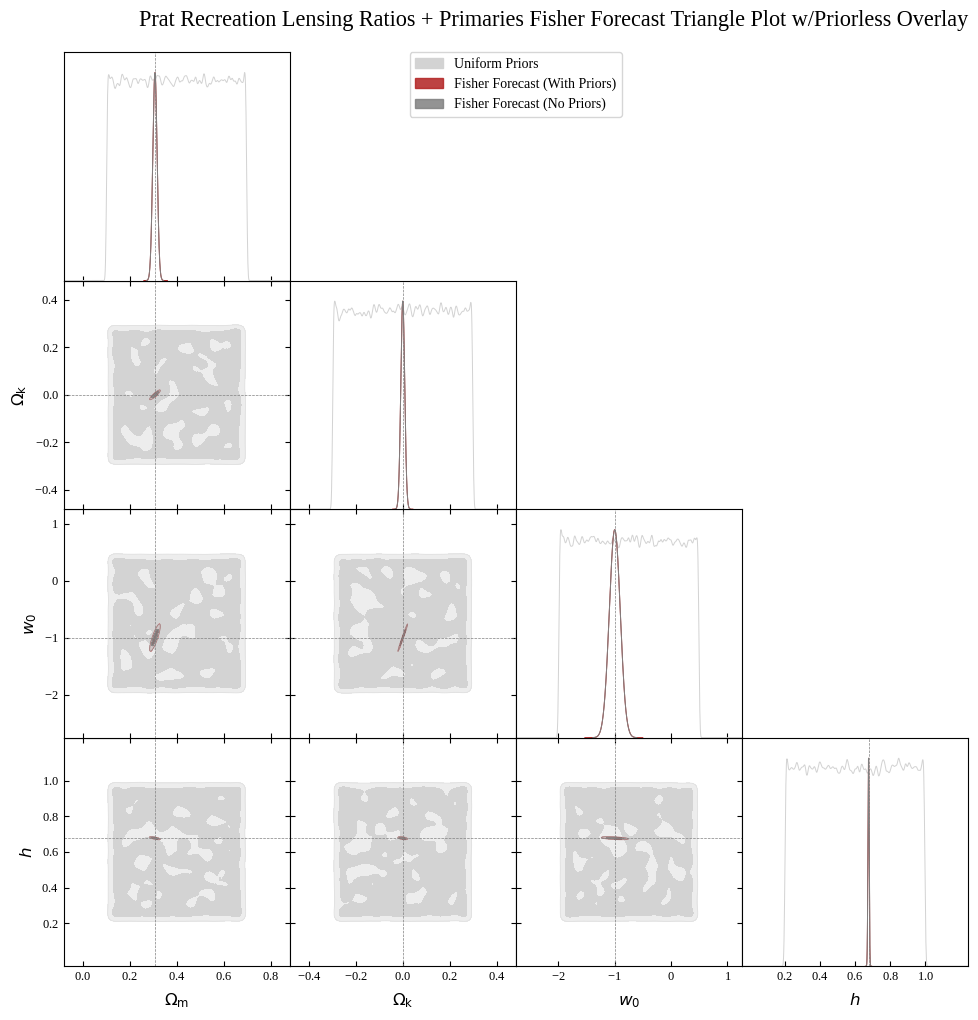

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


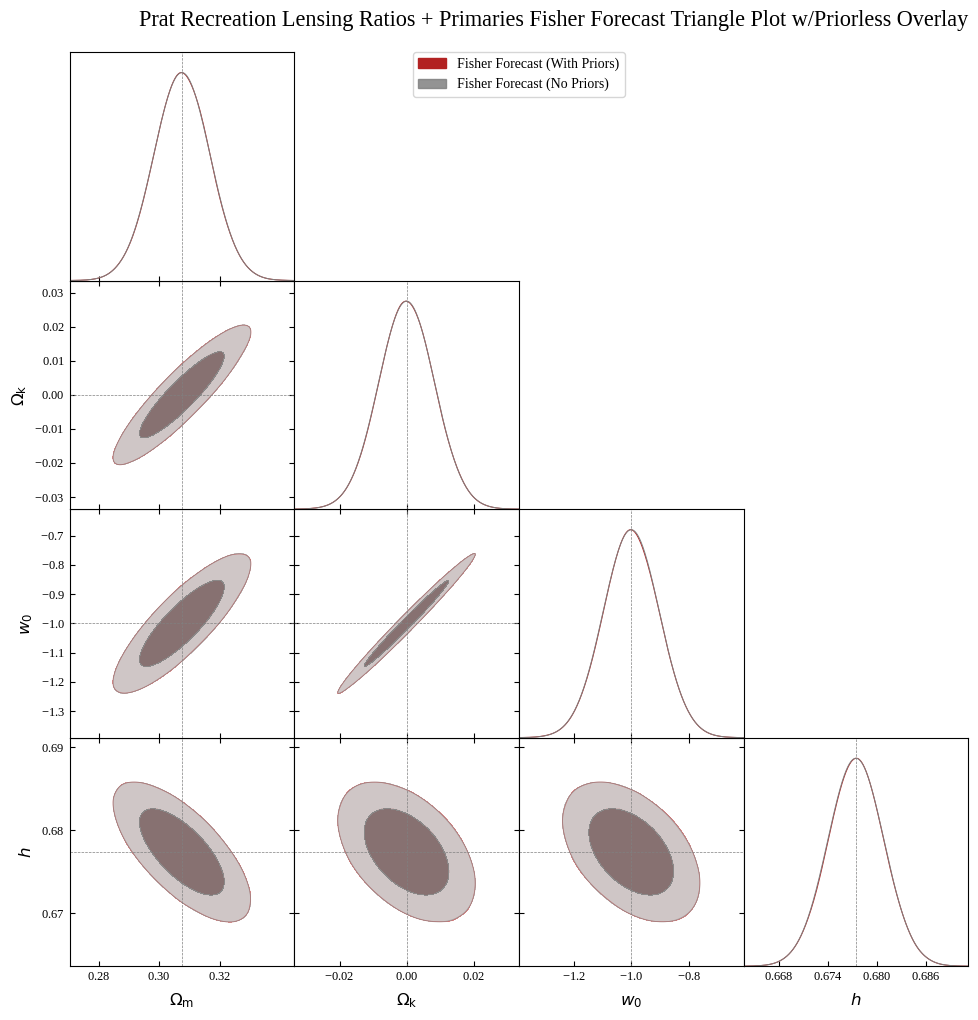

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


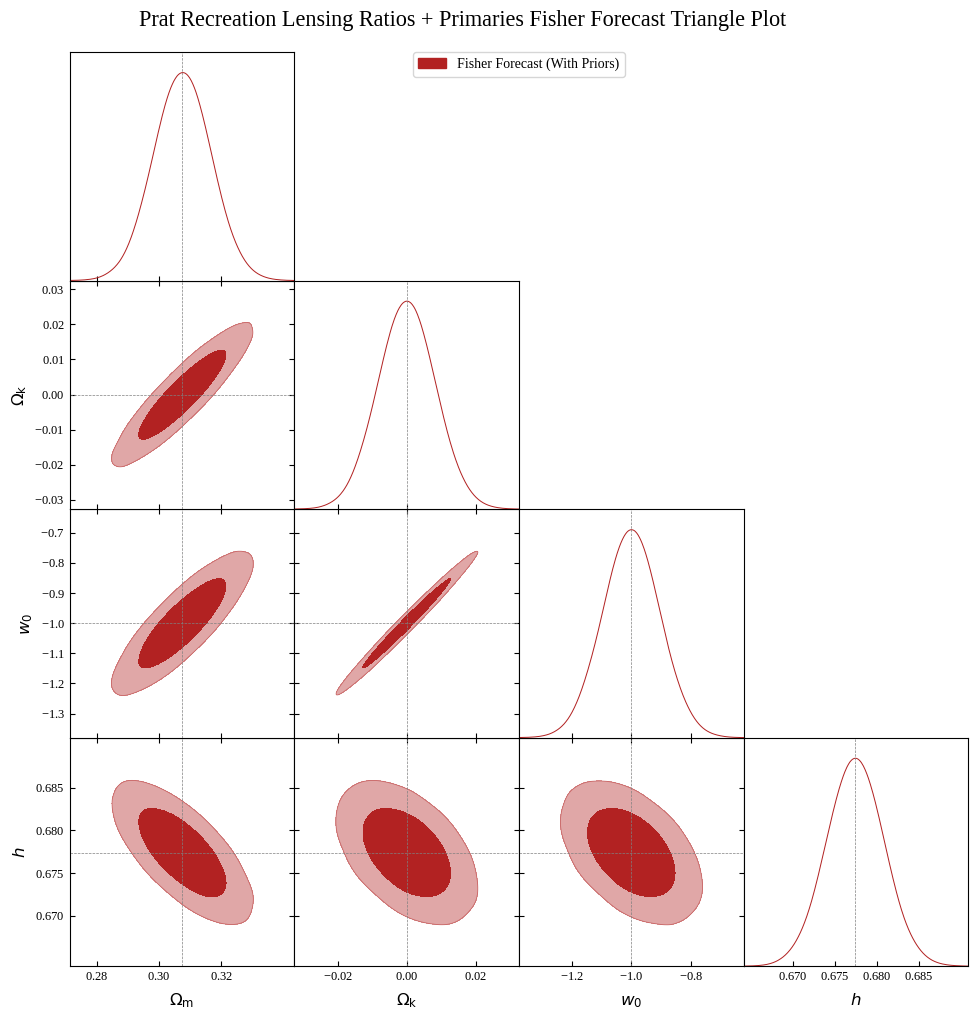

In [22]:
# Fisher forecast w/lensing ratios and primaries and four params (main three plus h)

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06, 
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0075$ | $\Omega_m = 0.308^{+0.015}_{-0.015}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0075$ | $\Omega_m = 0.307 \pm 0.015$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0085$ | $\Omega_k = 0.000^{+0.017}_{-0.017}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0085$ | $\Omega_k = 0.000 \pm 0.017$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.9998\pm 0.095$ | $w_0 = -1.00^{+0.19}_{-0.19}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.095$ | $w_0 = -1.000 \pm 0.190$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.04859\pm 0.00049$ | $\Omega_b = 0.04859^{+0.00097}_{-0.00097}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 4.86 \cdot 10^{-2} \pm 4.94 \cdot 10^{-4}$ | $\Omega_b = 4.86 \cdot 10^{-2} \pm 9.88 \cdot 10^{-4}$ |
| --- | --- | --- | --- |

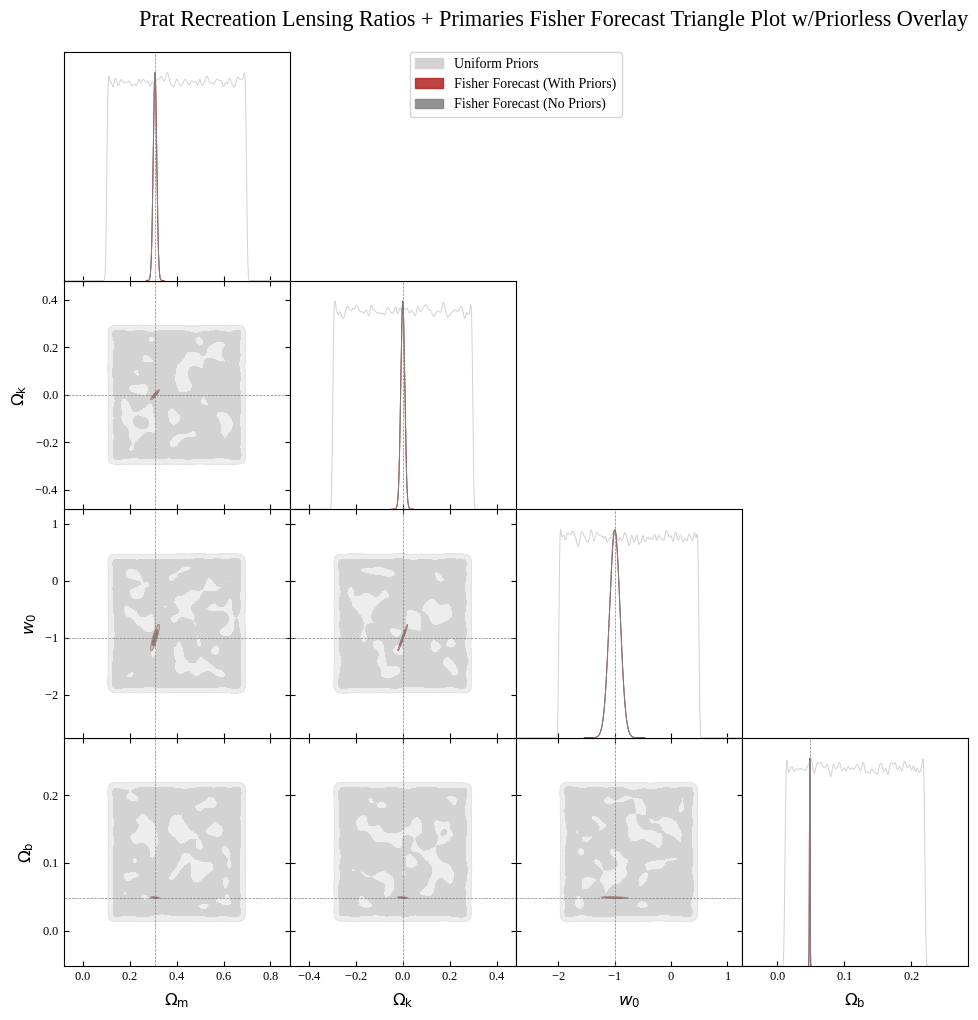

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


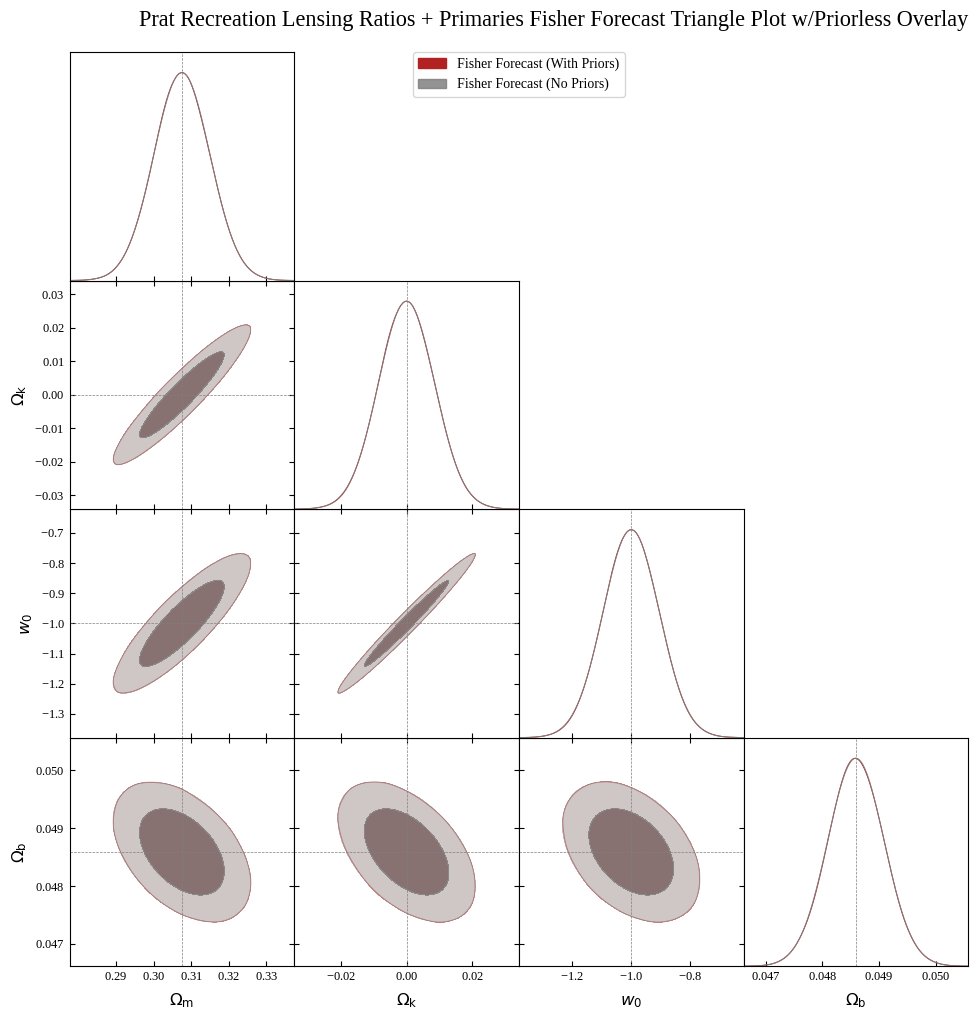

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


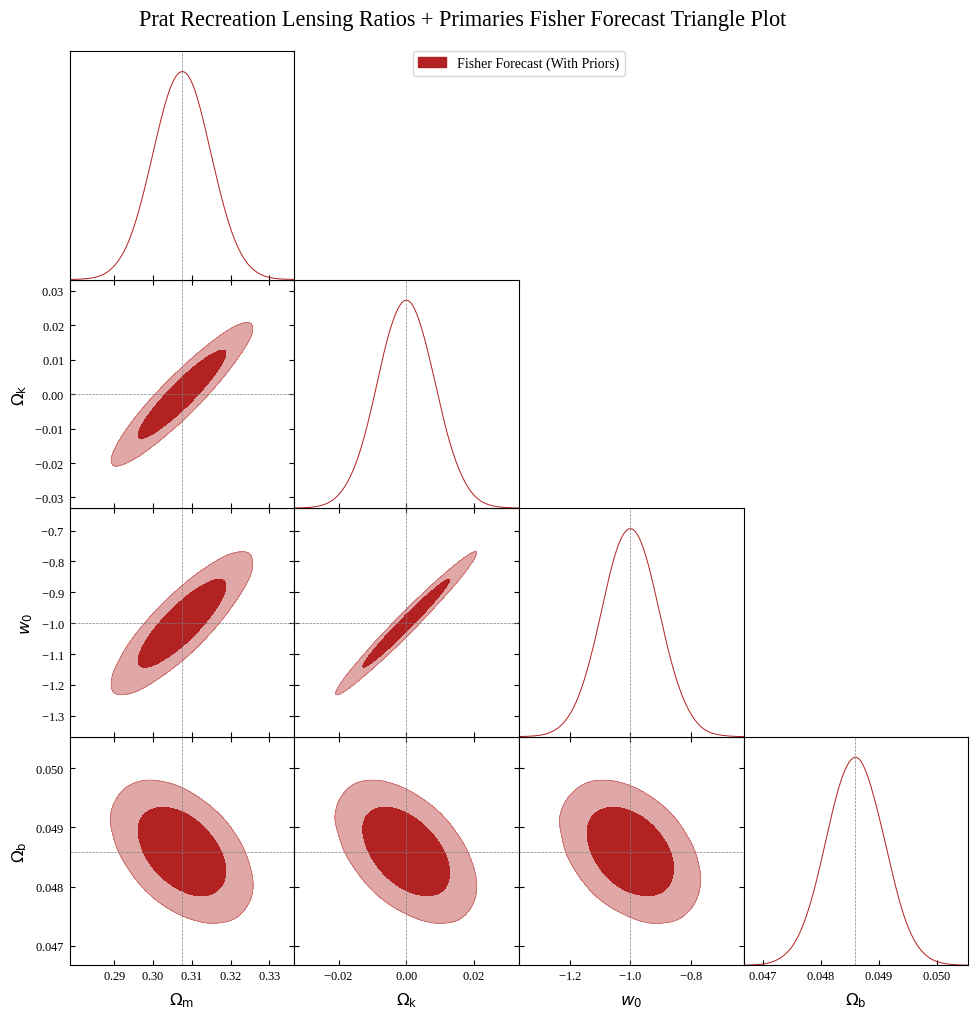

In [23]:
# Fisher forecast w/lensing ratios and primaries and four params (main three plus omega_b)

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06, 
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'Omega_b']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g3 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [ ]:
## Fisher forecasts with two parameters

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0028$ | $\Omega_m = 0.3075^{+0.0055}_{-0.0055}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0028$ | $\Omega_m = 0.3075 \pm 0.0056$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.016$ | $w_0 = -1.000^{+0.030}_{-0.031}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.016$ | $w_0 = -1.000 \pm 0.031$ |
| --- | --- | --- | --- |

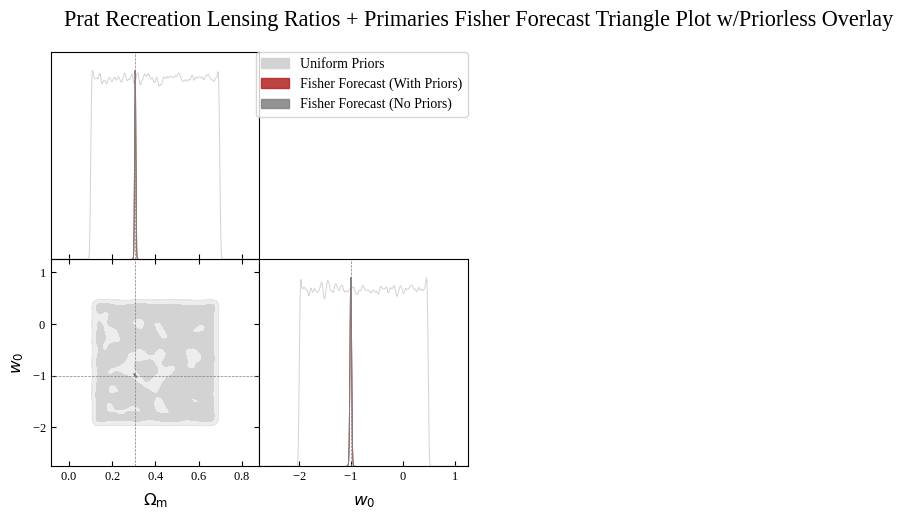

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


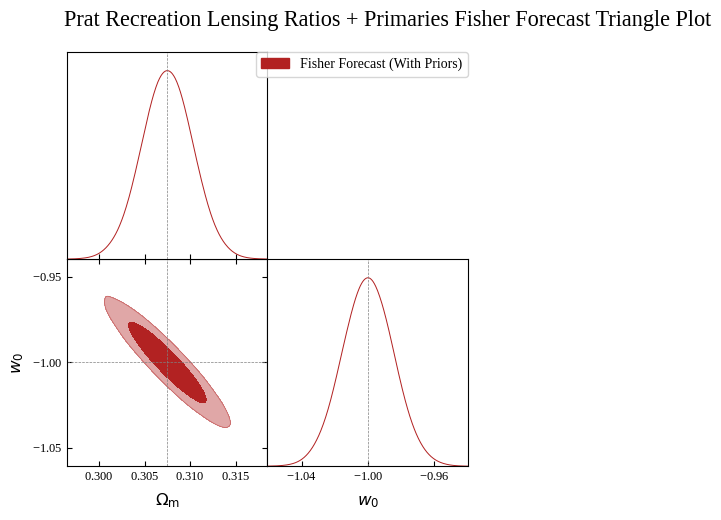

In [26]:
# Fisher forecast w/primaries and two params -- focus omega_m, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3089\pm 0.0038$ | $\Omega_m = 0.3089^{+0.0075}_{-0.0075}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3089 \pm 0.0038$ | $\Omega_m = 0.3089 \pm 0.0076$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0013$ | $\Omega_k = 0.0000^{+0.0026}_{-0.0026}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0013$ | $\Omega_k = 0.0000 \pm 0.0027$ |
| --- | --- | --- | --- |

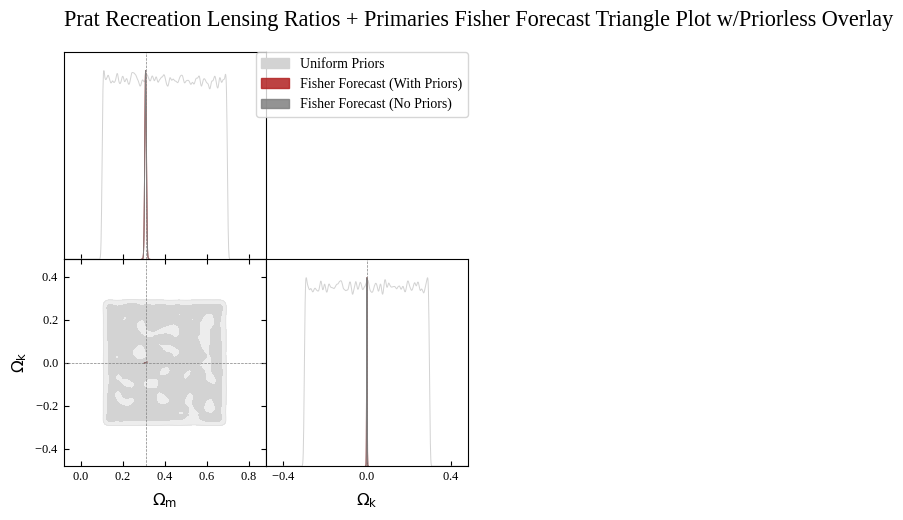

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


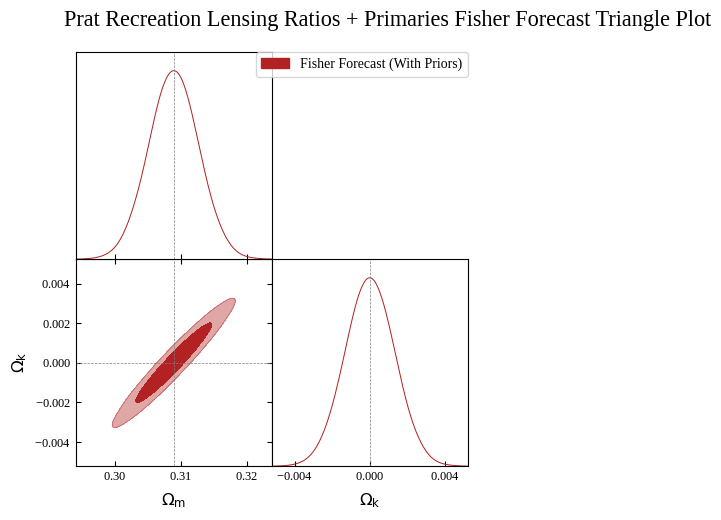

In [22]:
# Fisher forecast w/primaries and two params -- focus omega_m, omega_k

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'Omega_k': (-0.3, 0.3),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0031$ | $\Omega_k = 0.0000^{+0.0061}_{-0.0062}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0031$ | $\Omega_k = 0.0000 \pm 0.0063$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.050$ | $w_0 = -1.000^{+0.097}_{-0.098}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.050$ | $w_0 = -1.000 \pm 0.100$ |
| --- | --- | --- | --- |

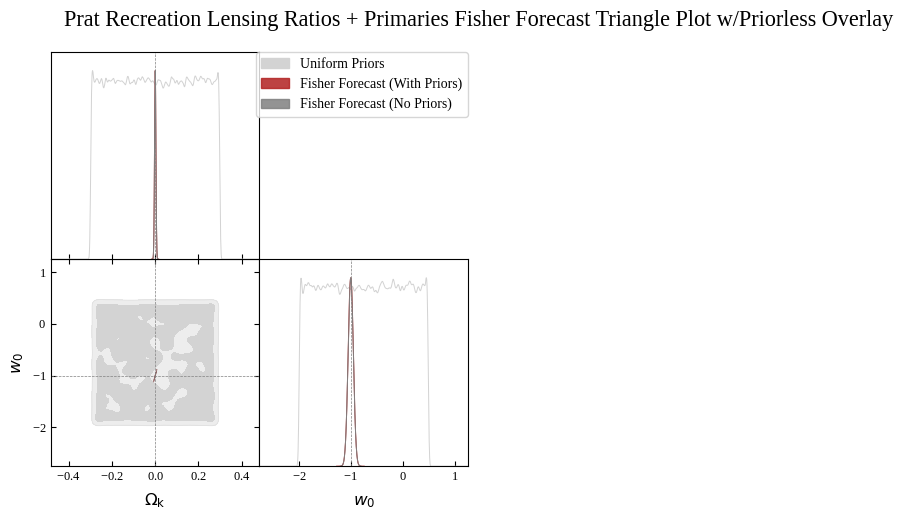

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


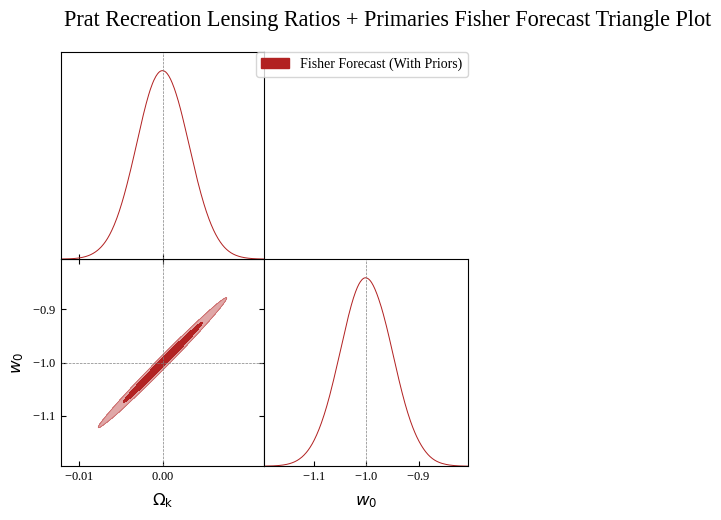

In [28]:
# Fisher forecast w/primaries and two params -- focus omega_k, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [11]:
## Fisher forecasts sampling set or subset of omega_c, omega_k, omega_b, h, w0 and plotting omega_m, omega_k, w0

chain_length:  199987
b_col:  3
c_col:  0
m_nu_col:  None
h_col:  4
b_samples:  [0.03699592 0.04957667 0.04881665 ... 0.05783063 0.04972142 0.06013073]
c_samples:  [0.19981416 0.26737548 0.24276857 ... 0.30964619 0.25615407 0.31010546]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
h_samples:  [0.75989301 0.67236505 0.67445537 ... 0.61413947 0.67263089 0.59567008]
Omega_nu_samples:  [0.00111548 0.00142481 0.001416   ... 0.00170779 0.00142369 0.00181534]
chain_length:  199987
chain_length:  199987


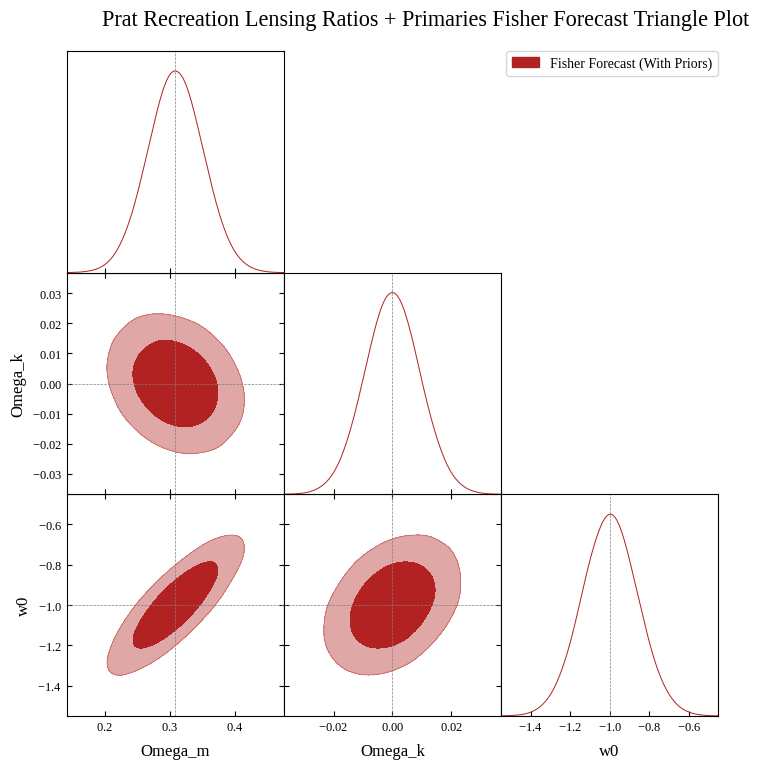

In [28]:
# Fisher forecast Prat recreation, sampling omega_c, omega_k, omega_b, h, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min=30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_k', 'w0', 'Omega_b', 'h']
params_to_plot = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    plot_params=params_to_plot,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

plt.show()

chain_length:  200000
b_col:  2
c_col:  None
m_nu_col:  None
h_col:  3
b_samples:  [0.04557457 0.0497531  0.04973209 ... 0.04698702 0.04890615 0.0470772 ]
c_samples:  [0.2589 0.2589 0.2589 ... 0.2589 0.2589 0.2589]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
h_samples:  [0.69129398 0.67367303 0.67143577 ... 0.68731617 0.67478652 0.67983976]
Omega_nu_samples:  [0.00134785 0.00141929 0.00142876 ... 0.0013635  0.00141461 0.00139365]
chain_length:  200000
chain_length:  200000


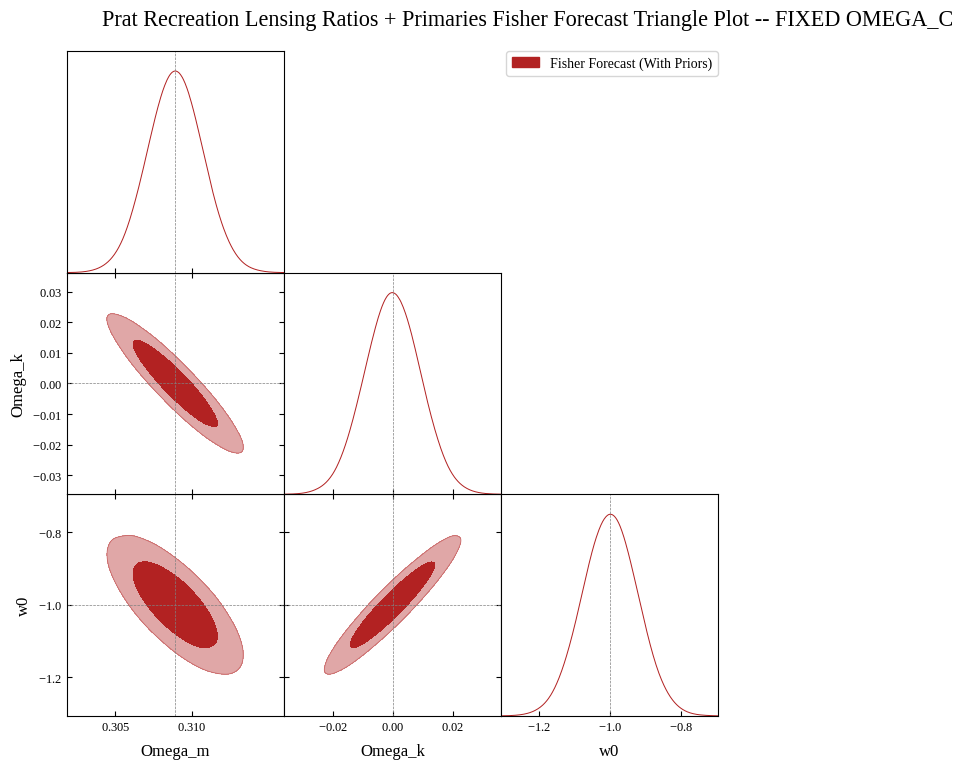

In [29]:
# Fisher forecast Prat recreation, sampling omega_b, omega_k, h, w0 -- FIXED OMEGA_C

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min=30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_k', 'w0', 'Omega_b', 'h']
params_to_plot = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_C",
    cobaya_chain_dir=None,
    plot_params=params_to_plot,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

plt.show()

chain_length:  200000
b_col:  None
c_col:  0
m_nu_col:  None
h_col:  3
b_samples:  [0.04859 0.04859 0.04859 ... 0.04859 0.04859 0.04859]
c_samples:  [0.24727416 0.25482807 0.25438235 ... 0.26004683 0.26772254 0.24679171]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
h_samples:  [0.68143353 0.68029183 0.67558359 ... 0.67852036 0.67391034 0.6820378 ]
Omega_nu_samples:  [0.00138714 0.0013918  0.00141127 ... 0.00139908 0.00141829 0.00138469]
chain_length:  200000
chain_length:  200000


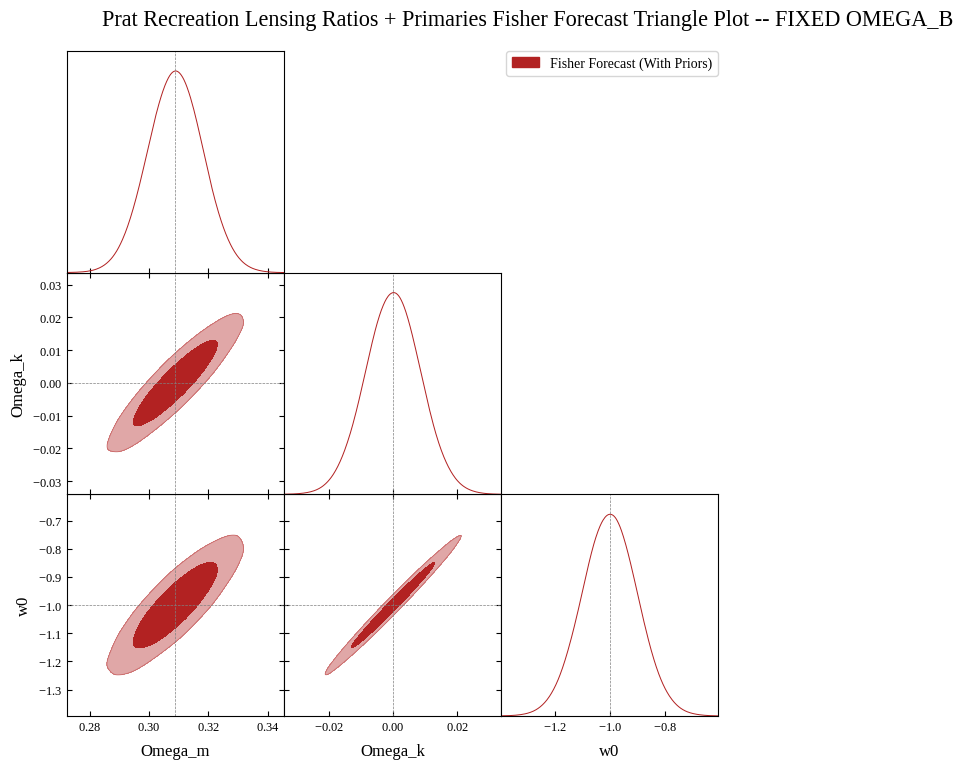

In [30]:
# Fisher forecast Prat recreation, sampling omega_c, omega_k, h, w0 -- FIXED OMEGA_B

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min=30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_k', 'w0', 'h']
params_to_plot = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_B",
    cobaya_chain_dir=None,
    plot_params=params_to_plot,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [ ]:
## Initial Thoughts (June 20 or so)
# The direction of the degeneracies is different than it is in Prat
# I've made several guesses along the way, but still I really don't like that
# The Fisher and MCMC agree very well, so I think the problem is in the shared parts of those pipelines, 
# namely in the covariance or vector building
# It would be interesting to find some prebuilt covariance matrix 
# and then try to build one with the same parameters and see what happens

## Das and Spergal Comparison

In [ ]:
## Prerun Thoughts:

# I'm having some issues because right now with omega_m set
# -- varying omega_k is just exactly the same as varying oemga_lambda
# I think they'll both be wrong
# The left graph shows omega_k increasing with omega_lambda
# This means omega_k increasing must cause a decrease in omega_m
# I don't get this result in my two-parameter sampling for Prat
# The right graph shows omega_lambda increasing with decreasing w0
# This means that decreasing w0 must decrease omega_m
# I don't get this result in my two-parameter sampling for Prat

# When I sample over Omega_m, Omega_k, and w0, increasing omega_m increases w0. 
# This means that increasing w0 would decrease Omega_lambda. 
# Meanwhile, increasing Omega_k increases Omega_m. 
# This means that increasing Omega_k would again decrease Omega_l which is NOT what we want.
# I'll run these for real, but I'm not hopeful.

# Fundamentally what I need is higher omega_m to mean lower omega_k.
# That way higher w0, which we see corresponds to lower omega_m, would correspond also to higher omega_k, which together might make for a lower omega_lambda.
# Also higher omega_k would correspond to lower omega_m which would correspond to higher omega_lambda.
# But I don't get that result! -- help!

# Something is fundamentally wrong here, cause just logically since 1 = omega_m + omega_k + omega_r + omega_l
# in a flat, modern universe, increasing omega_m should decrease omega_k
# I want to run this on MCMC and see what we get
# This is a major red flag
# Perhaps something in the definition of omega_m is going wrong?
# I could try doing omega_k omega_b or something...

In [ ]:
## Fisher for omega_k, omega_b and/or omega_c -- trying to figure out omega_m omega_k degeneracy

Raw datasets:  [<getdist.mcsamples.MCSamples object at 0x7fbc46a74450>]


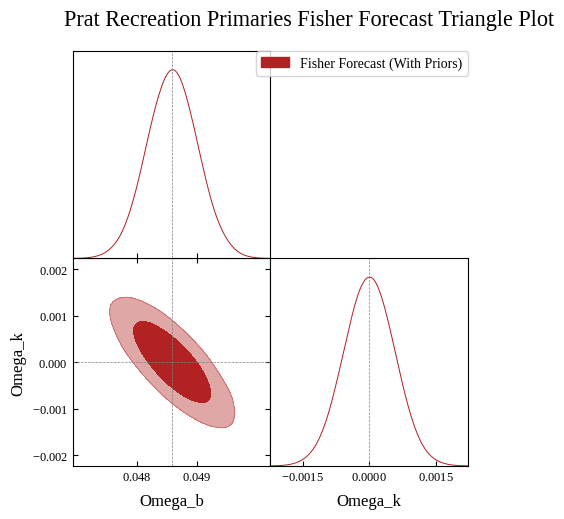

In [21]:
# Fisher forecast w/primaries and two params -- focus omega_k, omega_b

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_k': (-0.3, 0.3),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL','TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_b', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

plt.show()

Raw datasets:  [<getdist.mcsamples.MCSamples object at 0x7f1ac810be10>]


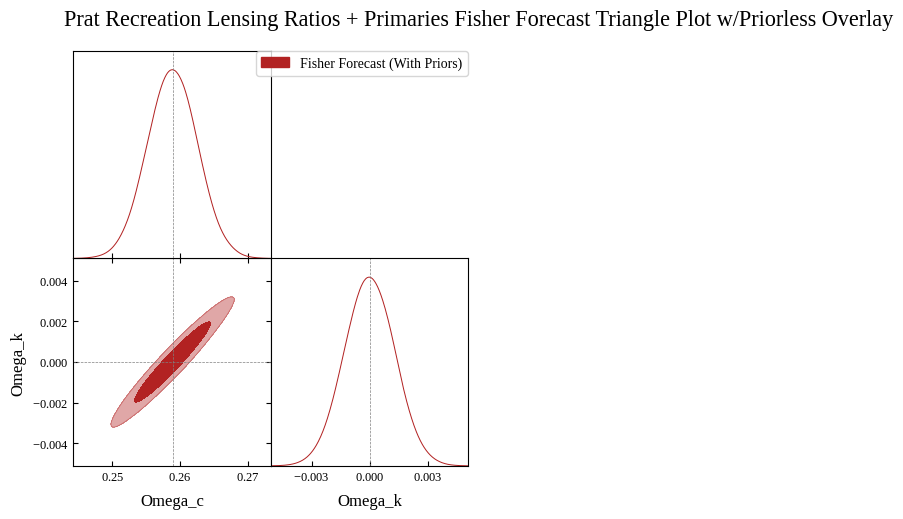

In [24]:
# Fisher forecast w/primaries and two params -- focus omega_k, omega_c

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_c': (0.1, 0.4),
    'Omega_k': (-0.3, 0.3),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_c', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

plt.show()

Raw datasets:  [<getdist.mcsamples.MCSamples object at 0x7fe71c30c850>]
Raw datasets:  [<getdist.mcsamples.MCSamples object at 0x7fe7c1ca6f50>]


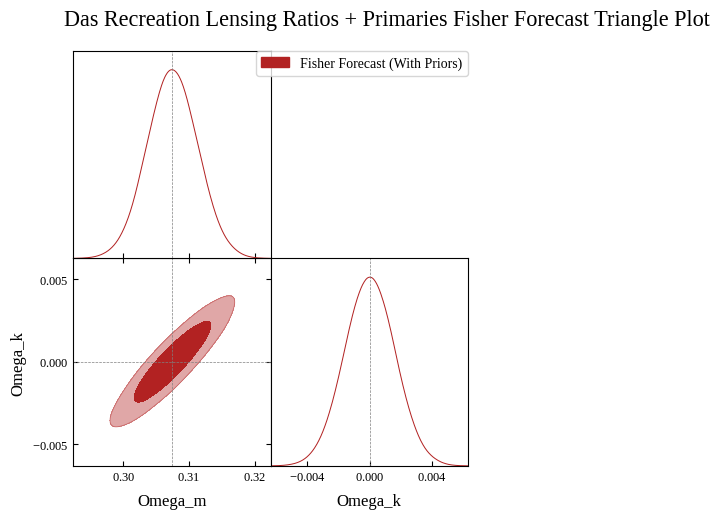

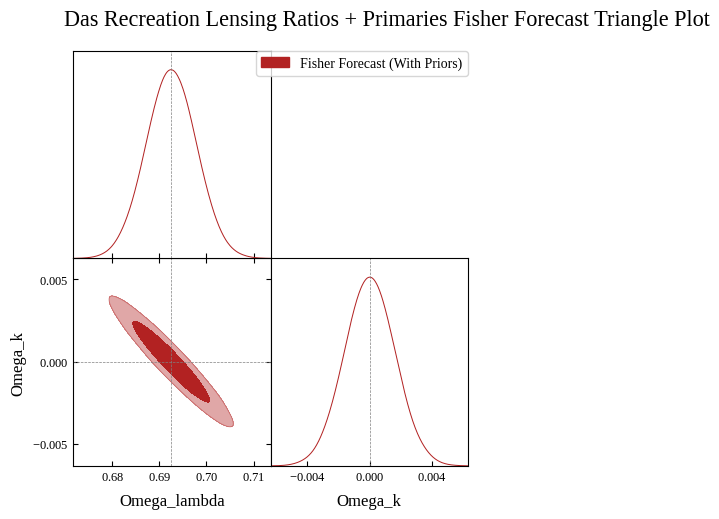

In [22]:
# Fisher forecast sampling over omega_c, omega_b but plotting omega_m...

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_c': (0.1, 0.4),
    'Omega_b': (0.01, 0.2),
    'Omega_k': (-0.3, 0.3)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min=30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'Omega_k']
params_to_plot1 = ['Omega_m', 'Omega_k']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params_to_plot1,
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params_to_sample,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params_to_plot2,
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params_to_sample,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

In [ ]:
## Fisher forecasts with omega_k, h, w0, omega_b and/or omega_c

chain_length:  199498
b_col:  0
c_col:  2
k_col:  None
m_nu_col:  None
h_col:  3
b_samples:  [0.05266291 0.03730838 0.0551633  ... 0.05126506 0.04087086 0.04416909]
c_samples:  [0.28336074 0.19189474 0.29149964 ... 0.27912996 0.21198703 0.23568502]
k_samples:  [0. 0. 0. ... 0. 0. 0.]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00153287 0.00112862 0.00159995 ... 0.0015106  0.00119424 0.00128112]
chain_length:  199498
chain_length:  199036
b_col:  0
c_col:  2
k_col:  3
m_nu_col:  None
h_col:  4
b_samples:  [0.05463315 0.05566364 0.05236515 ... 0.04865545 0.05270542 0.06484328]
c_samples:  [0.28213263 0.30536416 0.26602407 ... 0.24170693 0.28386863 0.34638071]
k_samples:  [-0.00636267  0.00612084 -0.0253654  ... -0.0172851   0.00454833
 -0.00829895]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00156308 0.00164391 0.00151529 ... 0.0013752  0.00152097 0.00201233]
chain_length:  199036


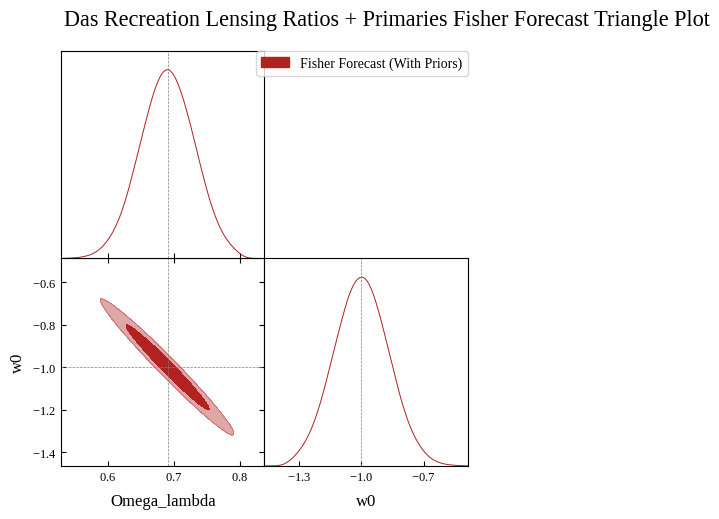

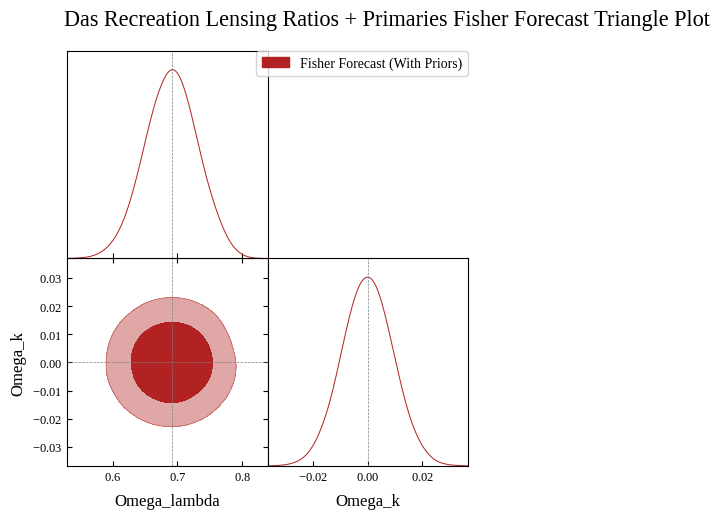

In [34]:
# Fisher forecast Das recreation, sampling omega_b, omega_k, omega_c, h, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 0.8)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

forecaster_c2 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample1 = ['Omega_b', 'w0', 'Omega_c', 'h']
params_to_plot1 = ['Omega_lambda', 'w0']
params_to_sample2 = ['Omega_b', 'w0', 'Omega_c', 'Omega_k', 'h']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample1)
F_raw_c2, cov_raw_c2 = forecaster_c2.make_fisher_matrix(desired_params=params_to_sample2)

# Call the unified class method to load, sample, overlay, and plot everything
g1 = forecaster_c1.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

g2 = forecaster_c2.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

chain_length:  200000
b_col:  0
c_col:  None
k_col:  None
m_nu_col:  None
h_col:  2
b_samples:  [0.04857429 0.04842429 0.04847161 ... 0.04987386 0.04789975 0.04876367]
c_samples:  [0.2589 0.2589 0.2589 ... 0.2589 0.2589 0.2589]
k_samples:  [0. 0. 0. ... 0. 0. 0.]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00138764 0.00140028 0.00138563 ... 0.00142899 0.00138999 0.00141215]
chain_length:  200000
chain_length:  200000
b_col:  0
c_col:  None
k_col:  2
m_nu_col:  None
h_col:  3
b_samples:  [0.04904704 0.04835327 0.04899379 ... 0.04992664 0.04489353 0.04577105]
c_samples:  [0.2589 0.2589 0.2589 ... 0.2589 0.2589 0.2589]
k_samples:  [-3.79321134e-03 -3.06026042e-03 -4.19677136e-05 ... -2.88072145e-03
  2.55512675e-02  1.55874209e-02]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140354 0.00139602 0.00142131 ... 0.00142999 0.00131736 0.00134287]
chain_length:  200000


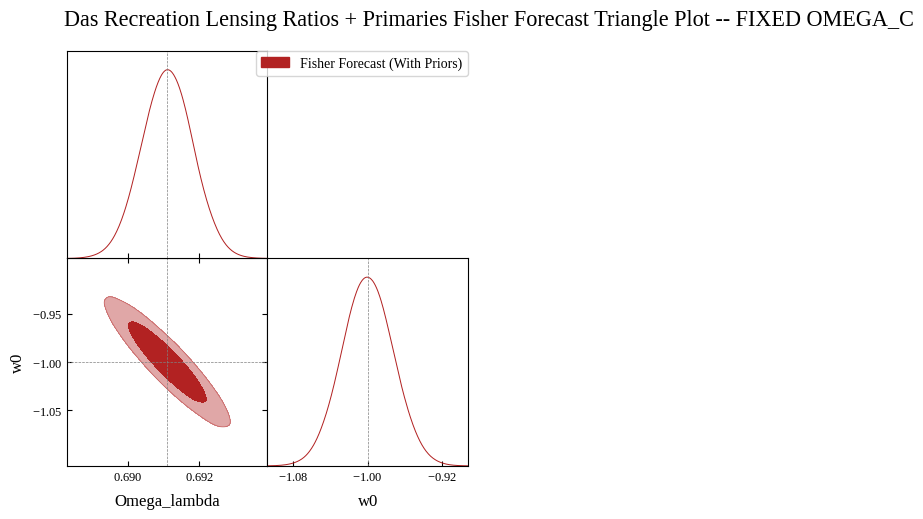

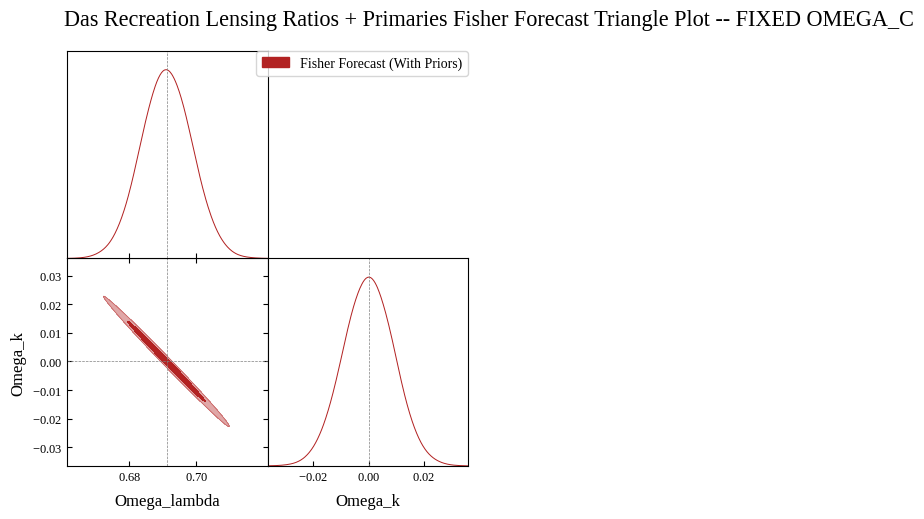

In [36]:
# Fisher forecast Das recreation, sampling omega_b, omega_k, w0, h -- FIXED OMEGA_C

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 0.8)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

forecaster_c2 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample1 = ['Omega_b', 'w0', 'h']
params_to_plot1 = ['Omega_lambda', 'w0']
params_to_sample2 = ['Omega_b', 'w0', 'Omega_k', 'h']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample1)
F_raw_c2, cov_raw_c2 = forecaster_c2.make_fisher_matrix(desired_params=params_to_sample2)

# Call the unified class method to load, sample, overlay, and plot everything
g1 = forecaster_c1.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_C",
    cobaya_chain_dir=None,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

g2 = forecaster_c2.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_C",
    cobaya_chain_dir=None,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

chain_length:  200000
b_col:  None
c_col:  0
k_col:  None
m_nu_col:  None
h_col:  2
b_samples:  [0.04859 0.04859 0.04859 ... 0.04859 0.04859 0.04859]
c_samples:  [0.26526029 0.2688694  0.2679886  ... 0.25862284 0.25658709 0.26229228]
k_samples:  [0. 0. 0. ... 0. 0. 0.]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00141914 0.00141007 0.00142212 ... 0.00140025 0.00140431 0.00140601]
chain_length:  200000
chain_length:  200000
b_col:  None
c_col:  0
k_col:  2
m_nu_col:  None
h_col:  3
b_samples:  [0.04859 0.04859 0.04859 ... 0.04859 0.04859 0.04859]
c_samples:  [0.27399282 0.24441154 0.25283703 ... 0.26285997 0.27183401 0.24601911]
k_samples:  [ 0.01778128 -0.01183747 -0.00861141 ... -0.00034686  0.00832118
 -0.01074731]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00141094 0.00138467 0.00140525 ... 0.00140942 0.00142773 0.00139866]
chain_length:  200000


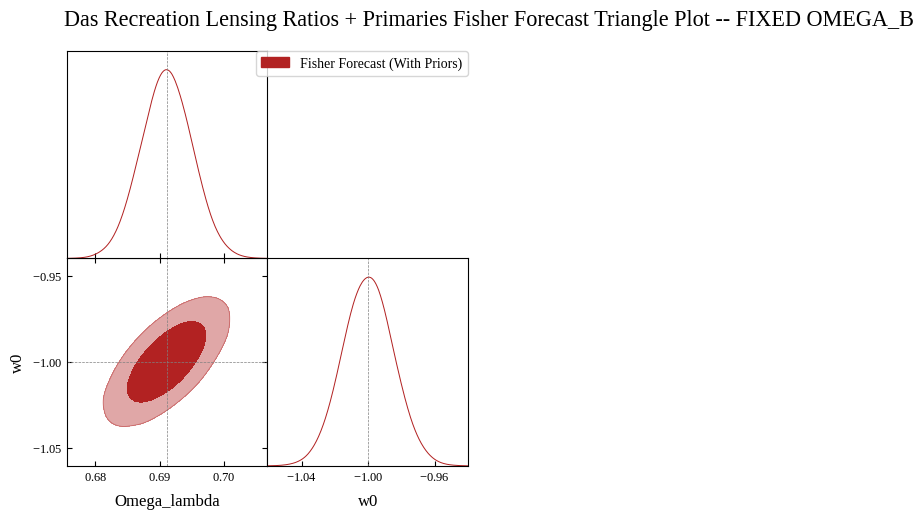

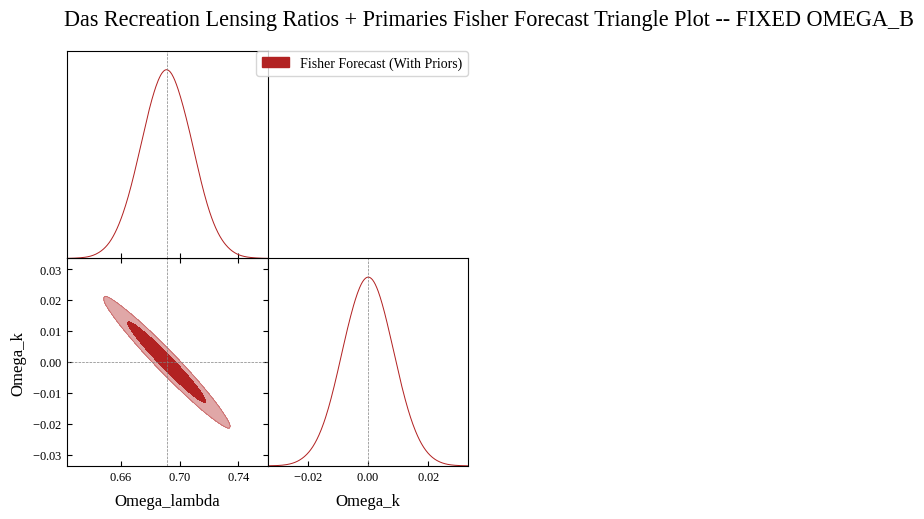

In [35]:
# Fisher forecast Das recreation, sampling omega_c, omega_k, h, w0 -- FIXED OMEGA_B

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 0.8)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

forecaster_c2 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample1 = ['Omega_c', 'w0', 'h']
params_to_plot1 = ['Omega_lambda', 'w0']
params_to_sample2 = ['Omega_c', 'w0', 'Omega_k', 'h']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample1)
F_raw_c2, cov_raw_c2 = forecaster_c2.make_fisher_matrix(desired_params=params_to_sample2)

# Call the unified class method to load, sample, overlay, and plot everything
g1 = forecaster_c1.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_B",
    cobaya_chain_dir=None,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

g2 = forecaster_c2.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_B",
    cobaya_chain_dir=None,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

In [ ]:
## Fisher with omega_k, w0, omega_b and/or omega_c

chain_length:  200000
b_col:  0
c_col:  2
k_col:  None
m_nu_col:  None
h_col:  None
b_samples:  [0.04780956 0.0478871  0.04839314 ... 0.04845962 0.0484618  0.0477615 ]
c_samples:  [0.2617929  0.2555502  0.2589043  ... 0.25605014 0.26243499 0.25503755]
k_samples:  [0. 0. 0. ... 0. 0. 0.]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140371 0.00140371 0.00140371 ... 0.00140371 0.00140371 0.00140371]
chain_length:  200000
chain_length:  200000
b_col:  0
c_col:  2
k_col:  3
m_nu_col:  None
h_col:  None
b_samples:  [0.04854485 0.04837533 0.04900309 ... 0.04865991 0.04851123 0.04777546]
c_samples:  [0.26760033 0.26305341 0.25643887 ... 0.25590983 0.24986587 0.27184046]
k_samples:  [ 0.00373946  0.00361088 -0.00581608 ... -0.00399113 -0.01082294
  0.01604296]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140371 0.00140371 0.00140371 ... 0.00140371 0.00140371 0.00140371]
chain_length:  200000


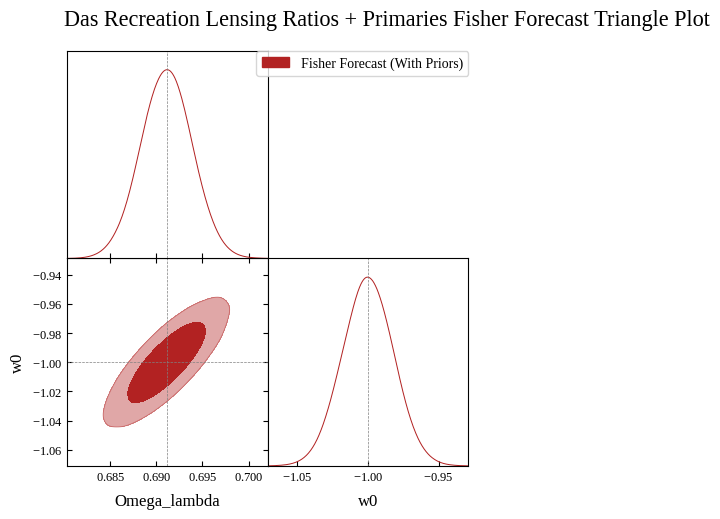

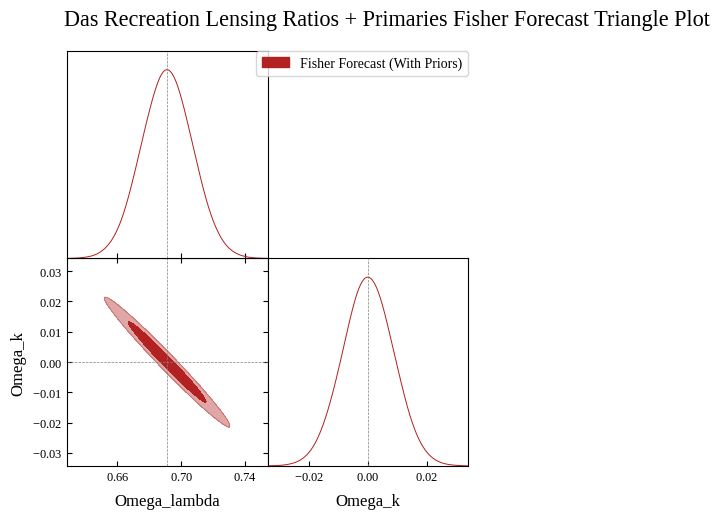

In [31]:
# Fisher forecast Das recreation, sampling omega_b, omega_k, omega_c, w0 

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_c': (0.1, 0.4),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

forecaster_c2 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample1 = ['Omega_b', 'w0', 'Omega_c']
params_to_plot1 = ['Omega_lambda', 'w0']
params_to_sample2 = ['Omega_b', 'w0', 'Omega_c', 'Omega_k']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample1)
F_raw_c2, cov_raw_c2 = forecaster_c2.make_fisher_matrix(desired_params=params_to_sample2)

# Call the unified class method to load, sample, overlay, and plot everything
g1 = forecaster_c1.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

g2 = forecaster_c2.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

chain_length:  200000
b_col:  0
c_col:  None
k_col:  None
m_nu_col:  None
h_col:  None
b_samples:  [0.04897235 0.04886055 0.04898865 ... 0.04854329 0.04943562 0.04956628]
c_samples:  [0.2589 0.2589 0.2589 ... 0.2589 0.2589 0.2589]
k_samples:  [0. 0. 0. ... 0. 0. 0.]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140371 0.00140371 0.00140371 ... 0.00140371 0.00140371 0.00140371]
chain_length:  200000
chain_length:  200000
b_col:  0
c_col:  None
k_col:  2
m_nu_col:  None
h_col:  None
b_samples:  [0.0483718  0.04898214 0.04861202 ... 0.04888181 0.04870908 0.04937013]
c_samples:  [0.2589 0.2589 0.2589 ... 0.2589 0.2589 0.2589]
k_samples:  [ 0.00083318 -0.00112739 -0.00182566 ...  0.00205839  0.00086142
 -0.00233961]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140371 0.00140371 0.00140371 ... 0.00140371 0.00140371 0.00140371]
chain_length:  200000


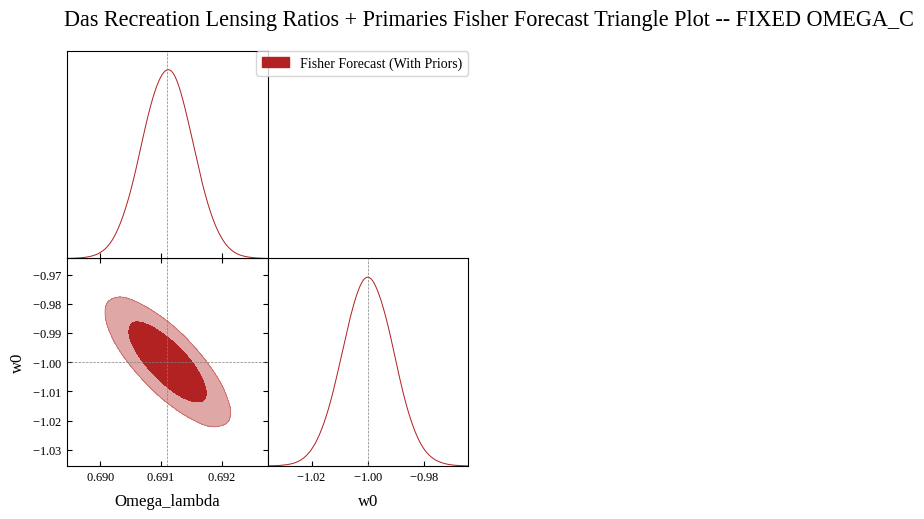

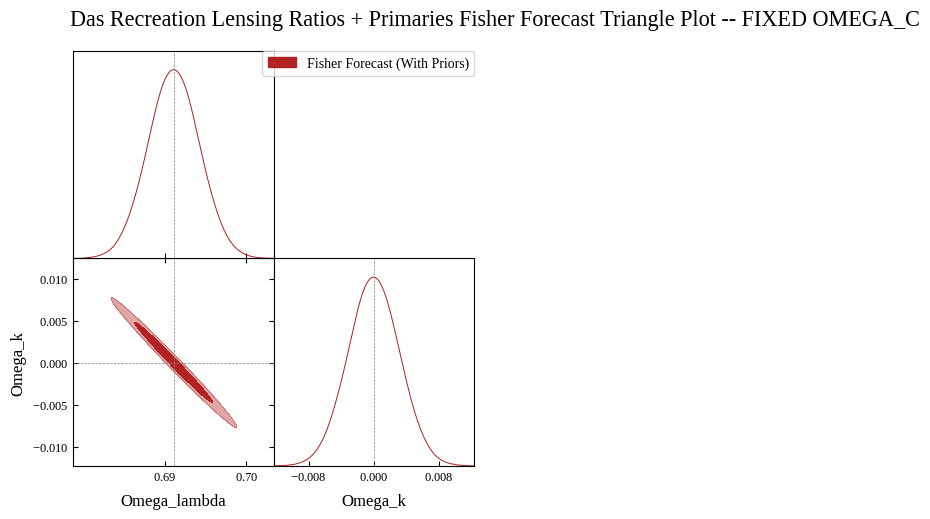

In [32]:
# Fisher forecast Das recreation, sampling omega_b, omega_k, w0 -- FIXED OMEGA_C

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_c': (0.1, 0.4),
    'Omega_k': (-0.3, 0.3),
    'w0': (-2, 0.5)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

forecaster_c2 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample1 = ['Omega_b', 'w0']
params_to_plot1 = ['Omega_lambda', 'w0']
params_to_sample2 = ['Omega_b', 'w0', 'Omega_k']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample1)
F_raw_c2, cov_raw_c2 = forecaster_c2.make_fisher_matrix(desired_params=params_to_sample2)

# Call the unified class method to load, sample, overlay, and plot everything
g1 = forecaster_c1.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_C",
    cobaya_chain_dir=None,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

g2 = forecaster_c2.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_C",
    cobaya_chain_dir=None,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

chain_length:  200000
b_col:  None
c_col:  1
k_col:  None
m_nu_col:  None
h_col:  None
b_samples:  [0.04859 0.04859 0.04859 ... 0.04859 0.04859 0.04859]
c_samples:  [0.25039394 0.25668434 0.26157892 ... 0.25481646 0.26026131 0.25901101]
k_samples:  [0. 0. 0. ... 0. 0. 0.]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140371 0.00140371 0.00140371 ... 0.00140371 0.00140371 0.00140371]
chain_length:  200000
chain_length:  200000
b_col:  None
c_col:  1
k_col:  2
m_nu_col:  None
h_col:  None
b_samples:  [0.04859 0.04859 0.04859 ... 0.04859 0.04859 0.04859]
c_samples:  [0.25447627 0.25765076 0.2615724  ... 0.26297451 0.25227844 0.25325244]
k_samples:  [-0.00463424 -0.00695084  0.00046152 ...  0.00783085 -0.0101143
 -0.00439638]
m_nu_samples:  [0.06 0.06 0.06 ... 0.06 0.06 0.06]
Omega_nu_samples:  [0.00140371 0.00140371 0.00140371 ... 0.00140371 0.00140371 0.00140371]
chain_length:  200000


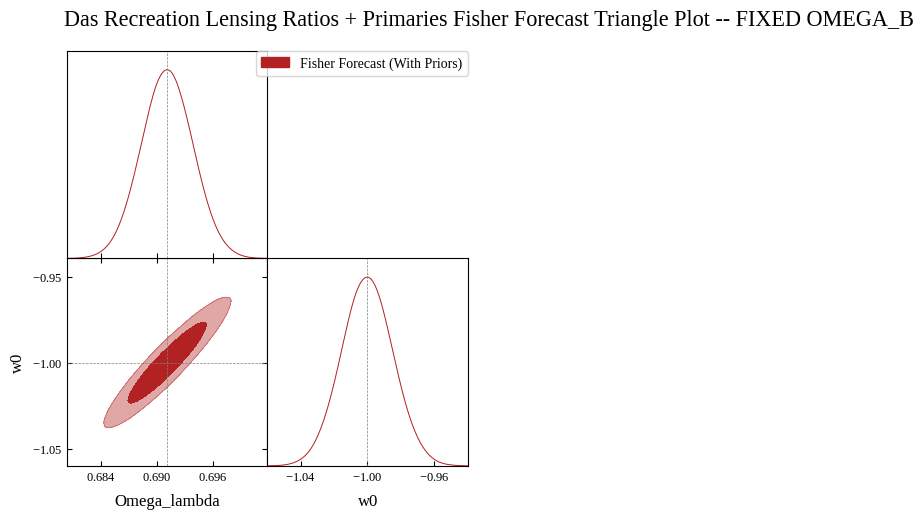

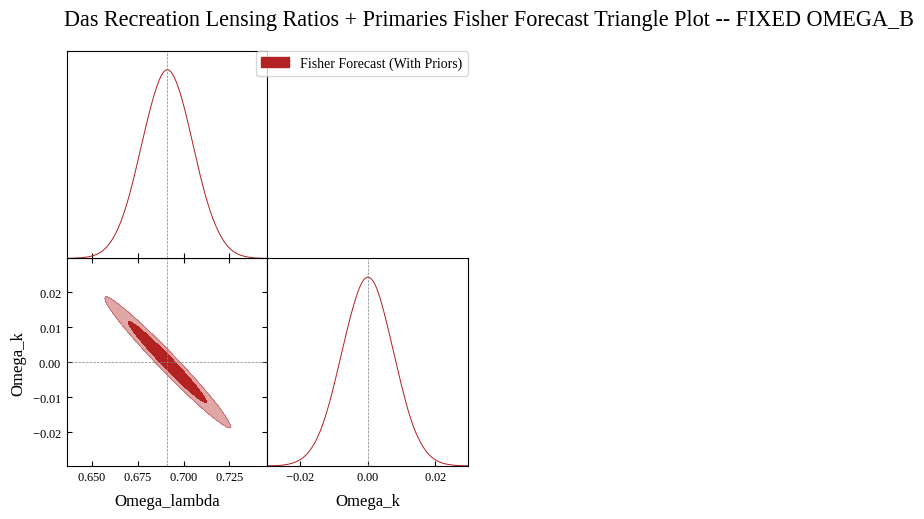

In [33]:
# Fisher forecast Das recreation, sampling omega_c, omega_k, w0 -- FIXED OMEGA_B

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    Neff=3.044, 
    m_nu=0.06,
    T_CMB=2.7255,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_b': (0.01, 0.2),
    'Omega_c': (0.1, 0.4),
    'Omega_k': (-0.3, 0.3),
    'w0': (-2, 0.5)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

forecaster_c2 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    l_min = 30,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise_kk,
    cmb_noise_TT=Prat_cmb_noise_TT,
    cmb_noise_EE=Prat_cmb_noise_EE,
    cmb_noise_TE=Prat_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample1 = ['w0', 'Omega_c']
params_to_plot1 = ['Omega_lambda', 'w0']
params_to_sample2 = ['w0', 'Omega_c', 'Omega_k']
params_to_plot2 = ['Omega_lambda', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample1)
F_raw_c2, cov_raw_c2 = forecaster_c2.make_fisher_matrix(desired_params=params_to_sample2)

# Call the unified class method to load, sample, overlay, and plot everything
g1 = forecaster_c1.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_B",
    cobaya_chain_dir=None,
    plot_params=params_to_plot1,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

g2 = forecaster_c2.plot_with_cobaya_overlay(
    title="Das Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot -- FIXED OMEGA_B",
    cobaya_chain_dir=None,
    plot_params=params_to_plot2,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = False,
    print_summary = False,
    plot_prior = False
)

In [ ]:
# why are my results not the same as Das when I plot omega_k against omega_lambda?
# maybe omega_m needs to change MORE drastically with changing omega_k....
# is the issue fundamentally that omega_c should decrease with increasing omega_k?

### SO/Planck Comparison Fisher -- Primaries Only

Plot successfully saved to: plots/Fisher Forecasts/so_primares_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0013$ | $\Omega_m = 0.3075^{+0.0025}_{-0.0025}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0013$ | $\Omega_m = 0.3075 \pm 0.0026$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0018$ | $h = 0.6774^{+0.0035}_{-0.0035}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0018$ | $h = 0.6774 \pm 0.0036$ |
| --- | --- | --- | --- |

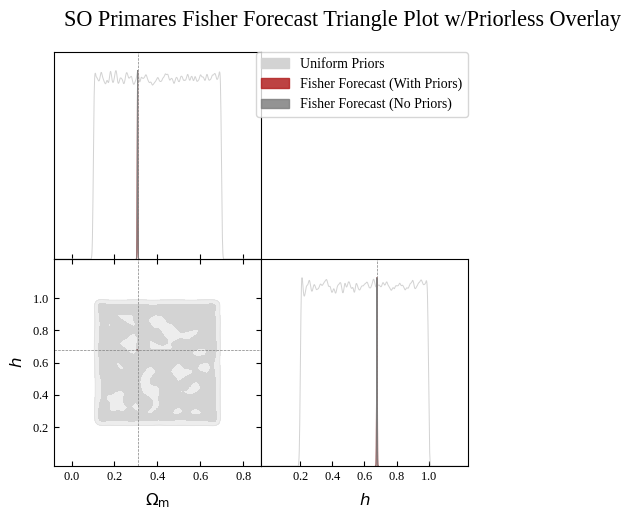

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_fisher_forecast_triangle_plot.pdf


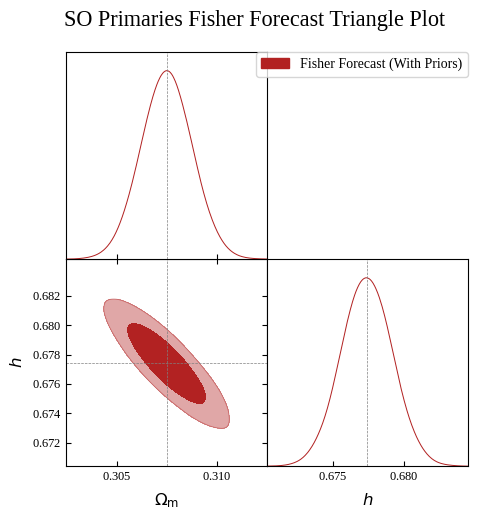

In [19]:
# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'h': (0.2, 1.0)
}
full_params = ['Omega_m', 'h']

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_1_5,
    binsize=50,
    n_ell = 5000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=None,
    shape_noise_source=None,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=full_params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primares Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True,
    num_samples = 200000
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    num_samples = 200000
)

plt.show()

Loading Planck 2018 chains...


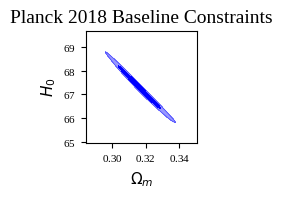

In [24]:
# Planck

# 1. Define the path to the specific chain folder you unzipped
# The unzip creates a nested 'base/plikHM_TTTEEE_lowl_lowE' directory structure
chain_dir = "./planck_chains/base/plikHM_TTTEEE_lowl_lowE"
chain_root = "base_plikHM_TTTEEE_lowl_lowE"

# 2. Load the chains using GetDist
print("Loading Planck 2018 chains...")
samples = mcsamples.loadMCSamples(f"{chain_dir}/{chain_root}", settings={'ignore_rows': 0.3})

# 3. Initialize the triangle plot
g = plots.get_subplot_plotter()

# 4. Plot a 2D contour of Omega_m vs. H0 (or any parameters in the .paramnames file)
# Note: Planck uses 'omegam' and 'H0' as parameter names
g.plot_2d(samples, 'omegam', 'H0', filled=True, colors=['blue'])

# Add title and adjust
plt.title("Planck 2018 Baseline Constraints", fontsize=14)
plt.show()

Plot successfully saved to: plots/Fisher Forecasts/so_primares_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0026$ | $\Omega_m = 0.3075^{+0.0051}_{-0.0052}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0026$ | $\Omega_m = 0.3075 \pm 0.0053$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0025$ | $h = 0.6774^{+0.0049}_{-0.0049}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0025$ | $h = 0.6774 \pm 0.0050$ |
| --- | --- | --- | --- |
| **$A_s$** | Uniform Priors | $A_s = \left(\,3.5\pm 1.1\,\right)\cdot 10^{-9}$ | $A_s = \left(\,3.5^{+1.9}_{-1.9}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (With Priors) | $A_s = \left(\,2.1410\pm 0.0091\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.141^{+0.018}_{-0.018}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = 2.14 \cdot 10^{-9} \pm 9.12 \cdot 10^{-12}$ | $A_s = 2.14 \cdot 10^{-9} \pm 1.82 \cdot 10^{-11}$ |
| --- | --- | --- | --- |

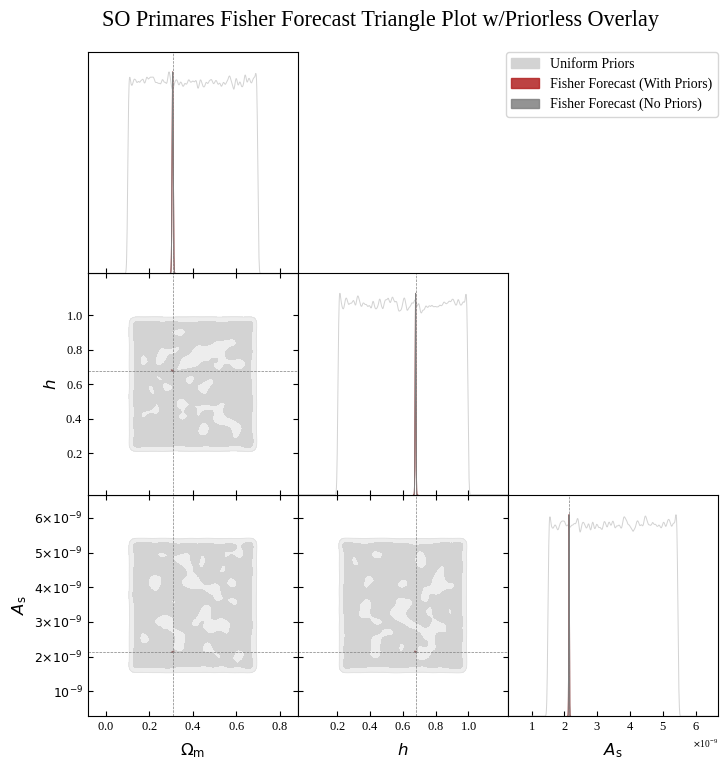

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_fisher_forecast_triangle_plot.pdf


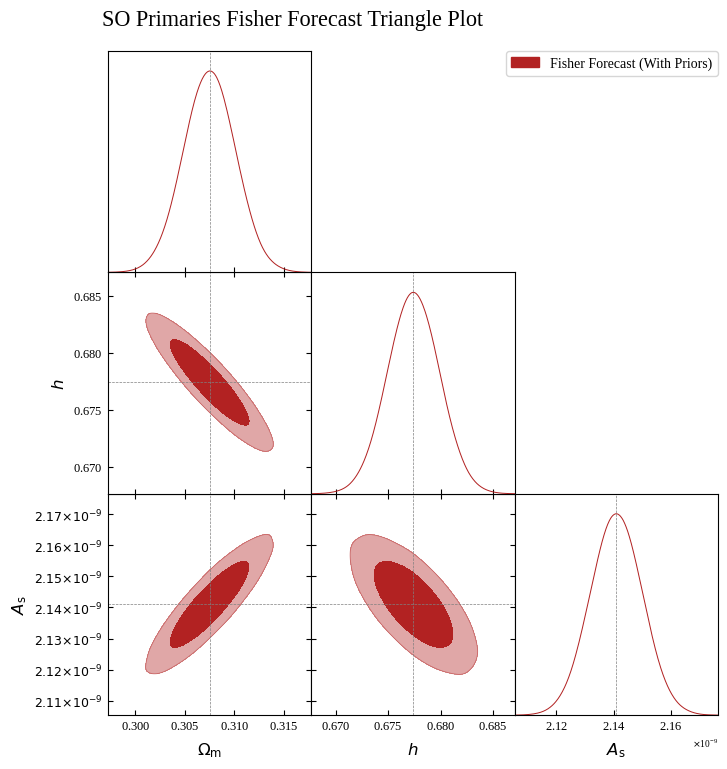

In [20]:
# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'h': (0.2, 1.0),
    'A_s': (1.48797e-9, 5.45981e-9)
}
full_params = ['Omega_m', 'h', 'A_s']

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_1_5,
    binsize=50,
    n_ell = 5000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=None,
    shape_noise_source=None,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=full_params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primares Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True,
    num_samples = 200000
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    num_samples = 200000
)

plt.show()

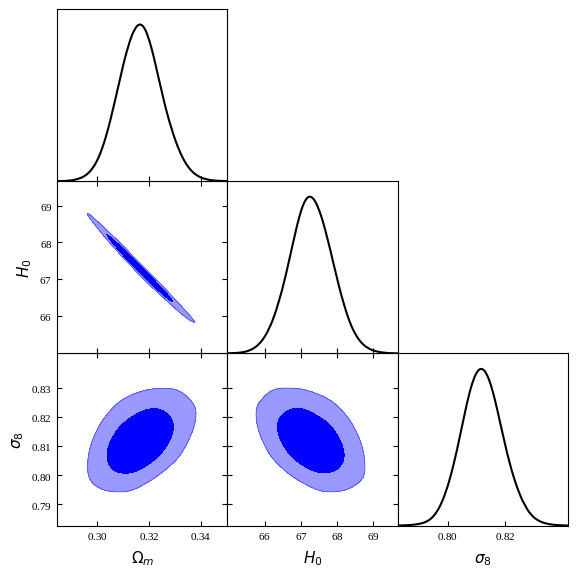

In [25]:
# 1. Initialize the subplot plotter for a triangle layout
g = plots.get_subplot_plotter()

# 2. Generate the full triangle contour plot
# Pass your samples and a list of the parameters you want to see
g.triangle_plot(
    samples, 
    ['omegam', 'H0', 'sigma8'], 
    filled=True, 
    colors=['blue'],
    line_args={'lw': 1.5}
)

# Show the full grid
plt.show()